# Startup Investment Outcome — Feature Selection & Modeling

**Input:** `data/train_resampled.csv`, `data/val_processed.csv`, `data/test_processed.csv`  
**Goal:** Select the most informative features using statistical tests and model-based importance methods, then train and compare multiple classifiers with regularization, selecting the best model for final evaluation on the test set.  
**Note:** All feature selection is fit on the **training set only**. Validation and test sets are transformed, never used to fit selectors.

This notebook follows the same structure as `04_Imbalanced_Data.ipynb`.  
Each section ends with a **→ Modeling Decision** box.

**Pipeline position:**
```
01_EDA → 02_... → 03_Preprocessing → 04_Imbalanced_Data → [05_Feature_Selection_Modeling] ← you are here
```

## 0. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Feature selection
from sklearn.feature_selection import (
    SelectKBest, f_classif, chi2,
    SelectFromModel, SequentialFeatureSelector
)

# Models
from sklearn.linear_model import LogisticRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight

# Evaluation
from sklearn.metrics import (
    confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score,
    roc_curve, auc, classification_report
)
from sklearn.preprocessing import label_binarize

# Permutation importance
from sklearn.inspection import permutation_importance

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')
pd.set_option('display.max_columns', 50)

STATUS_MAP   = {0: 'closed', 1: 'operating', 2: 'acquired'}
STATUS_NAMES = ['closed', 'operating', 'acquired']
COLORS       = ['#FF5722', '#2196F3', '#4CAF50']
RANDOM_STATE = 42

## 1. Load Data

The processed CSVs come from `03_Preprocessing.ipynb`. Notebook `04_Imbalanced_Data.ipynb` produces
five training files (one per resampling strategy). We need to pick **one** for Part A feature selection:

| File | Used for |
|------|----------|
| `train_resampled_smote.csv` | **Part A — feature selection** (default; change `FEATURE_SELECTION_FILE` if needed) |
| `train_resampled_ros.csv` | Part B — model training |
| `train_resampled_rus.csv` | Part B — model training |
| `train_resampled_smote.csv` | Part B — model training |
| `train_resampled_smotetomek.csv` | Part B — model training |

Using SMOTE for feature selection is a reasonable default — it produces a balanced,
synthesised dataset without simply duplicating rows (ROS) or discarding data (RUS).
If you want to use a different file, change `FEATURE_SELECTION_FILE` in the cell below.

**Raw funding columns** (`funding_total_usd`, `seed`, `venture`, …) are dropped here
because `FundingLogTransformer` in `03_Preprocessing` creates `log_<col>` versions
but does not remove the originals from the CSV.


In [2]:
# Feature selection needs one representative training set for fitting selectors.
# We use SMOTE as the default — it synthesises new minority samples rather than
# simply duplicating (ROS) or discarding (RUS), giving a balanced but realistic
# feature space for the selection methods to work on.
# All four resampling files are loaded in Part B (Section 11) for model training.
FEATURE_SELECTION_FILE = 'data/train_resampled_ros.csv'

train = pd.read_csv(FEATURE_SELECTION_FILE)
val   = pd.read_csv('data/val_processed.csv')
test  = pd.read_csv('data/test_processed.csv')

# ── Drop columns not used for modeling ────────────────────────────────────
# geo_cluster, market, country_code: target-encoded in 03_Preprocessing into
#   geo_cluster_enc_acquired / geo_cluster_enc_closed
#   market_category_enc_acquired / market_category_enc_closed
#   country_code_enc_acquired / country_code_enc_closed
# The original categorical columns are dropped by ColumnDropper in the pipeline,
# so they will not appear in the processed CSVs. No manual drop needed here.
#
# Raw funding columns: 03_Preprocessing applies log1p via FundingLogTransformer,
# producing log_<col> versions. The originals are left in the CSV but must NOT
# be fed to the model — using both raw + log would introduce redundancy and
# let the model bypass the intended transformation.
RAW_FUNDING_COLS = [
    'funding_total_usd', 'seed', 'venture', 'angel', 'grant',
    'private_equity', 'debt_financing', 'equity_crowdfunding',
    'convertible_note', 'undisclosed', 'product_crowdfunding',
    'post_ipo_equity', 'post_ipo_debt', 'secondary_market',
]

DROP_COLS = ['status_code'] + RAW_FUNDING_COLS

def prepare_X(df):
    cols_to_drop = [c for c in DROP_COLS if c in df.columns]
    return df.drop(columns=cols_to_drop)

X_train = prepare_X(train)
y_train = train['status_code']

X_val   = prepare_X(val)
y_val   = val['status_code']

X_test  = prepare_X(test)
y_test  = test['status_code']

# Verify log_ columns are present, raw columns are gone, and encoded features exist
log_funding_cols  = [c for c in X_train.columns if c.startswith('log_')]
raw_still_present = [c for c in RAW_FUNDING_COLS if c in X_train.columns]
enc_cols          = [c for c in X_train.columns if '_enc_' in c]
print(f"Feature selection train file : {FEATURE_SELECTION_FILE}")
print(f"Train shape : {X_train.shape}  |  Val: {X_val.shape}  |  Test: {X_test.shape}")
print(f"\nLog-transformed funding features ({len(log_funding_cols)}): {log_funding_cols}")
print(f"Raw funding cols remaining (should be 0): {raw_still_present}")
print(f"\nTarget-encoded features ({len(enc_cols)}): {enc_cols}")
print(f"\nAll features ({len(X_train.columns)}):")
print(list(X_train.columns))
print(f"\nClass distribution (train):")
for k, cnt in y_train.value_counts().sort_index().items():
    print(f"  {k} ({STATUS_MAP[k]:>10s}): {cnt:,}  ({cnt/len(y_train)*100:.1f}%)")


Feature selection train file : data/train_resampled_ros.csv
Train shape : (72294, 32)  |  Val: (5971, 32)  |  Test: (5971, 32)

Log-transformed funding features (14): ['log_funding_total_usd', 'log_seed', 'log_venture', 'log_angel', 'log_grant', 'log_private_equity', 'log_debt_financing', 'log_equity_crowdfunding', 'log_convertible_note', 'log_undisclosed', 'log_product_crowdfunding', 'log_post_ipo_equity', 'log_post_ipo_debt', 'log_secondary_market']
Raw funding cols remaining (should be 0): []

Target-encoded features (6): ['market_category_enc_acquired', 'market_category_enc_closed', 'geo_cluster_enc_acquired', 'geo_cluster_enc_closed', 'country_code_enc_acquired', 'country_code_enc_closed']

All features (32):
['funding_rounds', 'round_A', 'round_B', 'round_C', 'founded_year', 'founded_month', 'founded_quarter', 'log_funding_total_usd', 'log_seed', 'log_venture', 'log_angel', 'log_grant', 'log_private_equity', 'log_debt_financing', 'log_equity_crowdfunding', 'log_convertible_note',

## 2. Evaluation Helper

Reuse the same helper pattern from `04_Imbalanced_Data.ipynb` — consistent metrics across all notebooks.

In [3]:
def classification_metrics(y_true, y_pred, model_name=''):
    """Return a metrics dict for multiclass classification."""
    per_class = f1_score(y_true, y_pred, average=None, labels=[0, 1, 2])
    return {
        'Model':        model_name,
        'Accuracy':     accuracy_score(y_true, y_pred),
        'Macro F1':     f1_score(y_true, y_pred, average='macro'),
        'Weighted F1':  f1_score(y_true, y_pred, average='weighted'),
        'F1 closed':    per_class[0],
        'F1 operating': per_class[1],
        'F1 acquired':  per_class[2],
    }


def plot_confusion_matrix(y_true, y_pred, title='Confusion Matrix', ax=None):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=STATUS_NAMES, yticklabels=STATUS_NAMES, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    if ax is None:
        plt.tight_layout()
        plt.show()

---
# Part A — Feature Selection

We apply three complementary families of feature selection and aggregate their votes.

| Family | Methods |
|--------|---------|
| **Statistical (filter)** | ANOVA F-test, Chi-squared |
| **Model importance (wrapper)** | Random Forest, Gradient Boosting, Lasso, Ridge, Linear SVM |
| **Sequential wrapper** | Forward Selection (Random Forest base) |
| **Post-hoc** | Permutation Importance |

## 3. Statistical Feature Selection (Filter Methods)

Filter methods rank features **independently of any model**, using statistical tests to measure the relationship between each feature and the target.

### 3.1 ANOVA F-test (`f_classif`)

**ANOVA (Analysis of Variance)** tests whether the group means (per class) of a feature differ significantly.  
- High F-value → large variance *between* classes relative to variance *within* classes → feature discriminates well.  
- Low p-value → we can reject the null hypothesis that all class means are equal.

In [4]:
f_values, p_values = f_classif(X_train, y_train)

anova_df = pd.DataFrame({
    'Feature': X_train.columns,
    'F-Value': f_values,
    'P-Value': p_values
}).sort_values('F-Value', ascending=False).reset_index(drop=True)

print("ANOVA F-test results (sorted by F-value):")
display(anova_df.round(4))

ANOVA F-test results (sorted by F-value):


,Feature,F-Value,P-Value
0,log_funding_total_usd,5229.3154,0.0000
1,log_venture,3201.3481,0.0000
2,geo_cluster_enc_acquired,2363.0821,0.0000
3,has_round_B,1985.0274,0.0000
4,has_round_C,1682.1785,0.0000
5,country_code_enc_acquired,1601.7605,0.0000
6,funding_rounds,1414.8923,0.0000
7,market_category_enc_acquired,1391.9557,0.0000
8,market_category_enc_closed,1237.2776,0.0000
9,has_round_A,1203.2080,0.0000


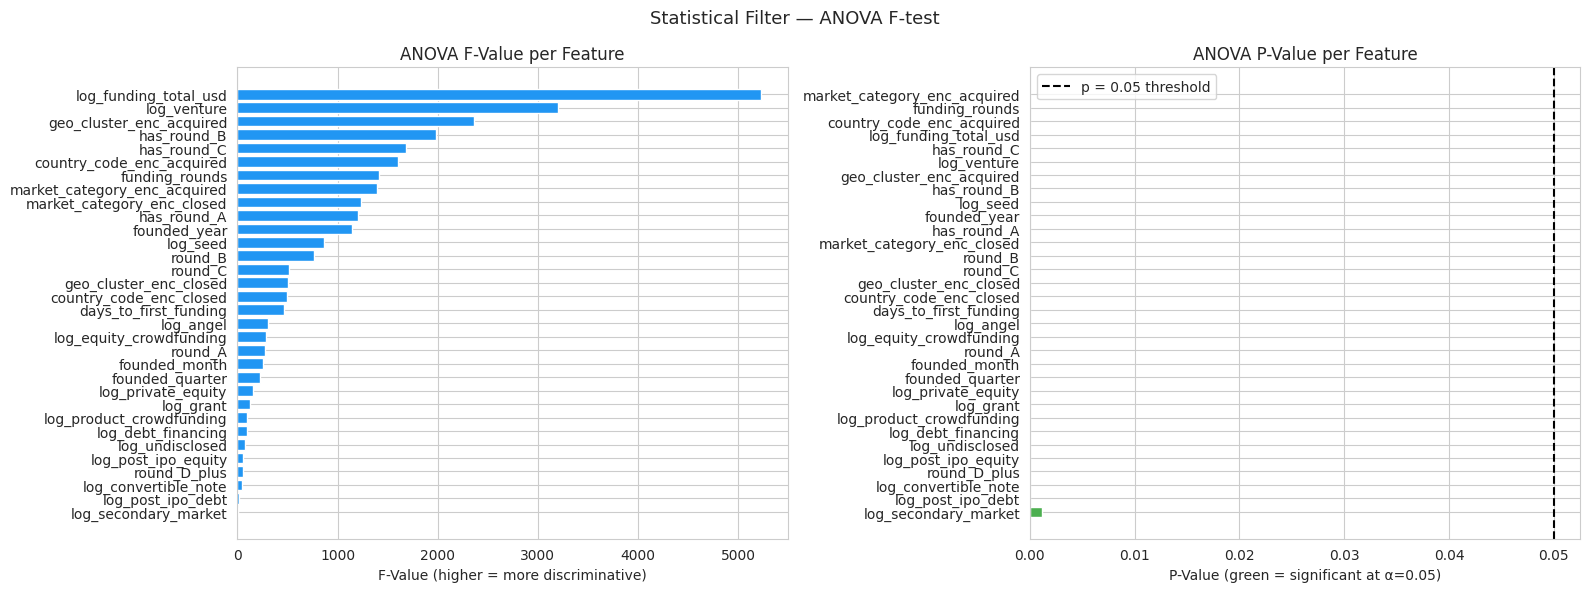


Features significant at α=0.05 (32): ['log_funding_total_usd', 'log_venture', 'geo_cluster_enc_acquired', 'has_round_B', 'has_round_C', 'country_code_enc_acquired', 'funding_rounds', 'market_category_enc_acquired', 'market_category_enc_closed', 'has_round_A', 'founded_year', 'log_seed', 'round_B', 'round_C', 'geo_cluster_enc_closed', 'country_code_enc_closed', 'days_to_first_funding', 'log_angel', 'log_equity_crowdfunding', 'round_A', 'founded_month', 'founded_quarter', 'log_private_equity', 'log_grant', 'log_product_crowdfunding', 'log_debt_financing', 'log_undisclosed', 'log_post_ipo_equity', 'round_D_plus', 'log_convertible_note', 'log_post_ipo_debt', 'log_secondary_market']


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# F-values bar chart
sorted_f = anova_df.sort_values('F-Value', ascending=True)
axes[0].barh(sorted_f['Feature'], sorted_f['F-Value'], color='#2196F3', edgecolor='white')
axes[0].set_title('ANOVA F-Value per Feature')
axes[0].set_xlabel('F-Value (higher = more discriminative)')

# P-values bar chart with significance line
sorted_p = anova_df.sort_values('P-Value', ascending=False)
bar_colors = ['#4CAF50' if p < 0.05 else '#FF5722' for p in sorted_p['P-Value']]
axes[1].barh(sorted_p['Feature'], sorted_p['P-Value'], color=bar_colors, edgecolor='white')
axes[1].axvline(0.05, color='black', linestyle='--', label='p = 0.05 threshold')
axes[1].set_title('ANOVA P-Value per Feature')
axes[1].set_xlabel('P-Value (green = significant at α=0.05)')
axes[1].legend()

plt.suptitle('Statistical Filter — ANOVA F-test', fontsize=13)
plt.tight_layout()
plt.show()

# Features significant at alpha = 0.05
anova_significant = anova_df[anova_df['P-Value'] < 0.05]['Feature'].tolist()
print(f"\nFeatures significant at α=0.05 ({len(anova_significant)}): {anova_significant}")

### 3.2 Chi-Squared Test (`chi2`)

Chi-squared tests the independence between each (non-negative) feature and the target.  
- Requires **non-negative** feature values — applicable to our scaled/encoded features that are ≥ 0.
- High χ² statistic → feature and target are strongly associated.

In [6]:
# Shift features to be non-negative for chi2
X_train_nonneg = X_train - X_train.min()

chi2_values, chi2_p = chi2(X_train_nonneg, y_train)

chi2_df = pd.DataFrame({
    'Feature':  X_train.columns,
    'Chi2':     chi2_values,
    'P-Value':  chi2_p
}).sort_values('Chi2', ascending=False).reset_index(drop=True)

print("Chi-Squared test results (sorted by Chi2 statistic):")
display(chi2_df.round(4))

chi2_significant = chi2_df[chi2_df['P-Value'] < 0.05]['Feature'].tolist()
print(f"\nFeatures significant at α=0.05 ({len(chi2_significant)}): {chi2_significant}")

Chi-Squared test results (sorted by Chi2 statistic):


,Feature,Chi2,P-Value
0,round_B,3.957880e+10,0.0000
1,round_C,3.457272e+10,0.0000
2,round_D_plus,1.587042e+10,0.0000
3,round_A,8.913570e+09,0.0000
4,days_to_first_funding,1.049758e+06,0.0000
5,log_venture,3.447318e+04,0.0000
6,log_seed,1.523477e+04,0.0000
7,log_angel,7.209026e+03,0.0000
8,log_equity_crowdfunding,6.758442e+03,0.0000
9,funding_rounds,5.899156e+03,0.0000



Features significant at α=0.05 (32): ['round_B', 'round_C', 'round_D_plus', 'round_A', 'days_to_first_funding', 'log_venture', 'log_seed', 'log_angel', 'log_equity_crowdfunding', 'funding_rounds', 'log_private_equity', 'log_funding_total_usd', 'log_grant', 'has_round_B', 'has_round_C', 'founded_month', 'log_product_crowdfunding', 'log_debt_financing', 'log_undisclosed', 'log_post_ipo_equity', 'has_round_A', 'log_convertible_note', 'founded_quarter', 'log_post_ipo_debt', 'founded_year', 'log_secondary_market', 'geo_cluster_enc_acquired', 'market_category_enc_acquired', 'country_code_enc_acquired', 'market_category_enc_closed', 'geo_cluster_enc_closed', 'country_code_enc_closed']


In [7]:
# SelectKBest — top K features by ANOVA
K = min(10, len(X_train.columns))
selector_anova = SelectKBest(score_func=f_classif, k=K)
selector_anova.fit(X_train, y_train)

anova_top_k = X_train.columns[selector_anova.get_support()].tolist()
print(f"Top {K} features by ANOVA SelectKBest: {anova_top_k}")

# Binary selection mask for voting (1 if in top K)
anova_selected = selector_anova.get_support().astype(int)

Top 10 features by ANOVA SelectKBest: ['funding_rounds', 'log_funding_total_usd', 'log_venture', 'has_round_A', 'has_round_B', 'has_round_C', 'market_category_enc_acquired', 'market_category_enc_closed', 'geo_cluster_enc_acquired', 'country_code_enc_acquired']


> **→ Modeling Decision (Filter Methods):** Features with low ANOVA p-values and high chi-squared statistics are strong individual predictors. These filters are fast and model-agnostic, but they don't capture interactions — we use them as one vote in the ensemble.

## 4. Correlation Analysis

Highly correlated features carry redundant information. We remove one from each highly correlated pair to reduce multicollinearity before model-based selection.

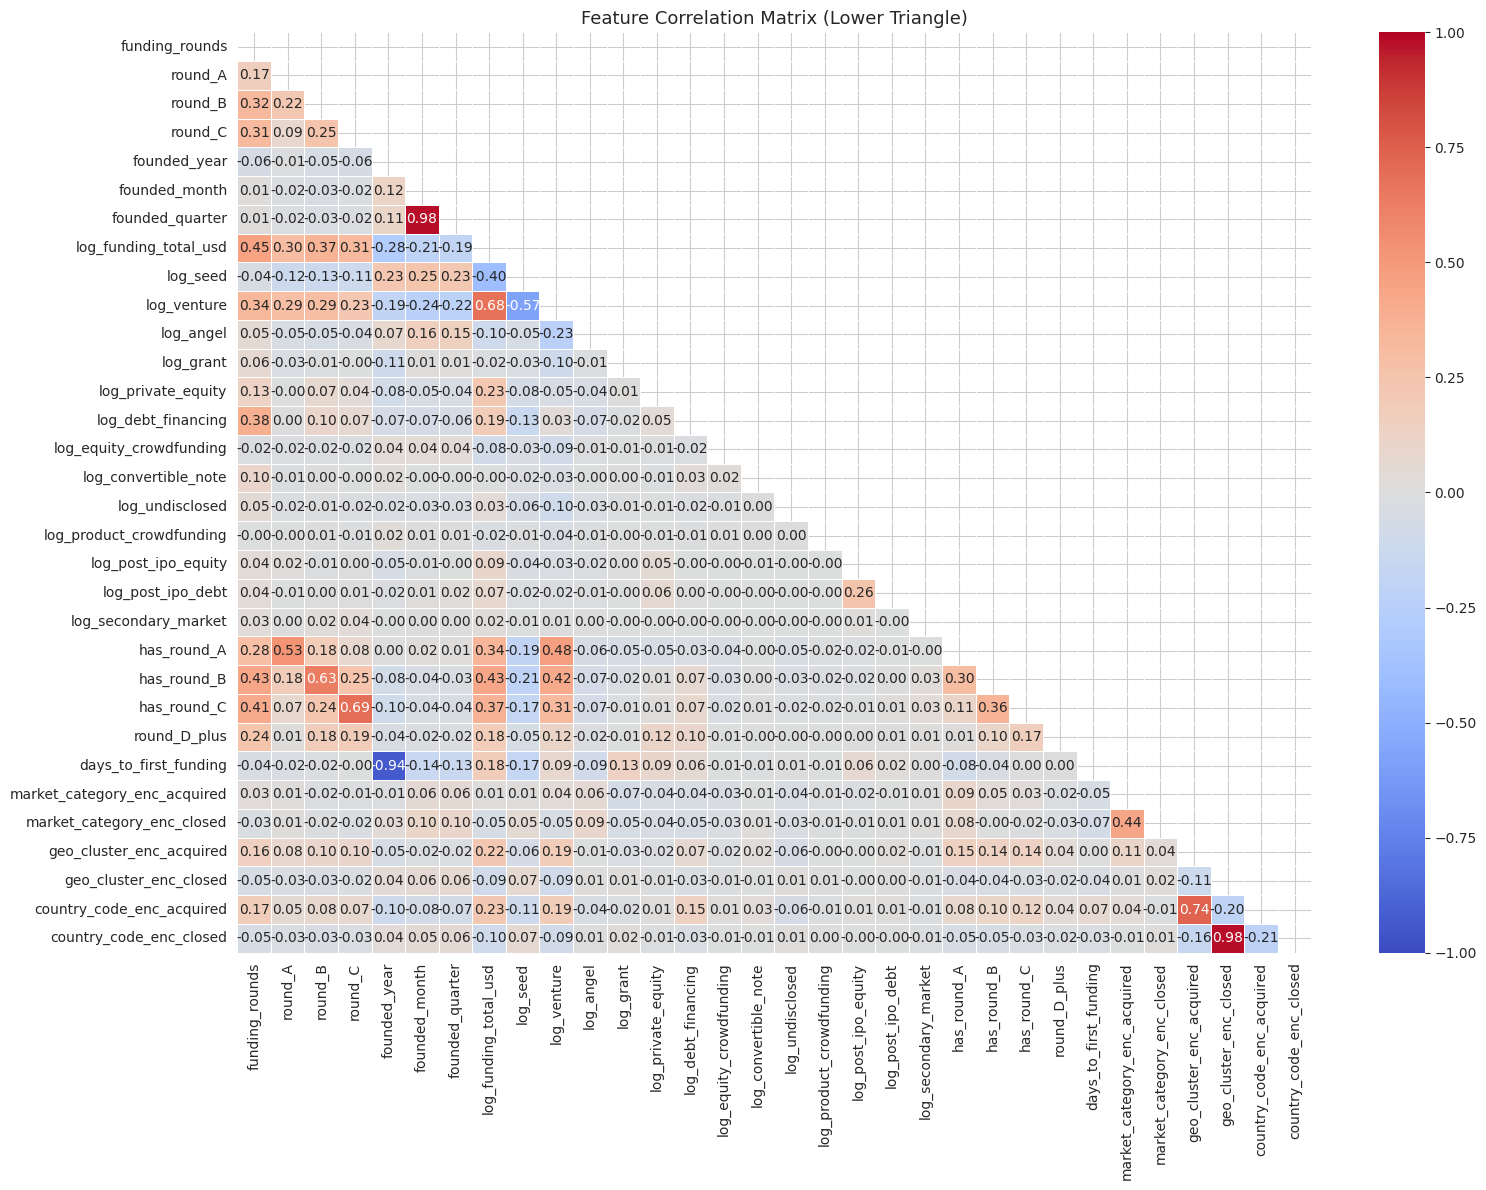

In [8]:
correlation_matrix = X_train.corr()

plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=0.5, mask=mask, vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix (Lower Triangle)', fontsize=13)
plt.tight_layout()
plt.show()

In [9]:
CORRELATION_THRESHOLD = 0.7

corr_abs  = correlation_matrix.abs()
upper_tri = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))

# For each correlated pair, drop the one with the lower ANOVA F-value
f_value_map = dict(zip(anova_df['Feature'], anova_df['F-Value']))

to_drop_corr = set()
for col in upper_tri.columns:
    for row in upper_tri.index:
        if upper_tri.loc[row, col] > CORRELATION_THRESHOLD:
            # Keep the feature with the higher F-value, drop the other
            if f_value_map.get(row, 0) >= f_value_map.get(col, 0):
                to_drop_corr.add(col)
            else:
                to_drop_corr.add(row)

ALWAYS_KEEP = ['days_to_first_funding']  # add any features you want protected here
to_drop_corr = [f for f in to_drop_corr if f not in ALWAYS_KEEP]

to_drop_corr = list(to_drop_corr)
print(f"Correlation threshold : {CORRELATION_THRESHOLD}")
print(f"Original features     : {X_train.shape[1]}")
print(f"Features to drop      : {to_drop_corr}")
print(f"Remaining features    : {X_train.shape[1] - len(to_drop_corr)}")



Correlation threshold : 0.7
Original features     : 32
Features to drop      : ['country_code_enc_acquired', 'country_code_enc_closed', 'founded_quarter']
Remaining features    : 29


> **→ Modeling Decision:** Features with pairwise correlation > 0.7 are candidates for removal. We note which features are collinear and consider dropping the one with the lower ANOVA F-value in the final selection.

## 5. Model-Based Feature Importance (Wrapper Methods)

Wrapper methods evaluate feature importance **through model training**. Each method uses a different mechanism:

| Method | Mechanism |
|--------|-----------|
| **Random Forest** | Mean impurity decrease (Gini) across trees |
| **Gradient Boosting** | Feature usage frequency × gain in all trees |
| **Lasso (L1)** | Shrinks less-useful coefficients to exactly zero |
| **Ridge (L2)** | Shrinks coefficients toward zero — retains all features |
| **Linear SVM (L1)** | Sparse weight vector via L1 penalty |

In [10]:
# --- Random Forest ---
rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)
rf_selected = (rf.feature_importances_ > 0).astype(int)
print(f"Random Forest — features with importance > 0: {rf_selected.sum()}")

Random Forest — features with importance > 0: 32


In [11]:
# --- Gradient Boosting ---
gb = GradientBoostingClassifier(n_estimators=200, random_state=RANDOM_STATE)
gb.fit(X_train, y_train)
gb_selected = (gb.feature_importances_ > 0).astype(int)
print(f"Gradient Boosting — features with importance > 0: {gb_selected.sum()}")

Gradient Boosting — features with importance > 0: 32


In [12]:
# --- Lasso (L1) ---
# Lasso performs feature selection by zeroing out less-relevant coefficients.
# Higher alpha = stronger penalty = more features zeroed out.
lasso = LogisticRegression(penalty='l1', solver='saga', C=0.1,
                            random_state=RANDOM_STATE, max_iter=2000,
                            multi_class='ovr')
lasso.fit(X_train, y_train)
# For multiclass: a feature is selected if any class has a non-zero coefficient
lasso_selected = (np.abs(lasso.coef_).sum(axis=0) > 1e-6).astype(int)
print(f"Lasso (L1 Logistic) — features selected: {lasso_selected.sum()}")

Lasso (L1 Logistic) — features selected: 0


In [13]:
# --- Ridge (L2) ---
# Ridge shrinks coefficients toward zero but rarely sets them exactly to zero.
# Useful for identifying relatively less informative features (very low coefs).
ridge = LogisticRegression(penalty='l2', solver='lbfgs', C=1.0,
                            random_state=RANDOM_STATE, max_iter=2000,
                            multi_class='ovr')
ridge.fit(X_train, y_train)
# Select features whose total absolute coefficient across classes is above median
ridge_coef_sum = np.abs(ridge.coef_).sum(axis=0)
ridge_selected = (ridge_coef_sum > np.median(ridge_coef_sum)).astype(int)
print(f"Ridge (L2 Logistic) — features above median coef magnitude: {ridge_selected.sum()}")

Ridge (L2 Logistic) — features above median coef magnitude: 16


In [14]:
# --- Linear SVM with L1 penalty ---
# LinearSVC with L1 penalty produces sparse weight vectors (feature selection).
svm = LinearSVC(C=0.1, penalty='l1', dual=False, random_state=RANDOM_STATE, max_iter=3000)
svm.fit(X_train, y_train)
svm_selected = (np.abs(svm.coef_).sum(axis=0) > 1e-6).astype(int)
print(f"Linear SVM (L1) — features selected: {svm_selected.sum()}")

Linear SVM (L1) — features selected: 28


## 6. Forward Sequential Feature Selection

Forward selection greedily adds the feature that most improves cross-validated performance at each step.  
It captures **feature interactions** that filter methods miss.

In [15]:
sfs_estimator = RandomForestClassifier(
    n_estimators=30,        # was 100 — enough for selection, not final modeling
    max_depth=8,            # cap depth to speed up each fit
    random_state=RANDOM_STATE,
    n_jobs=-1
)

sfs = SequentialFeatureSelector(
    sfs_estimator,
    n_features_to_select=10,   # was 'auto' — set a fixed cap instead of open-ended
    direction='forward',
    scoring='f1_macro',
    cv=3,
    n_jobs=-1
)
sfs.fit(X_train, y_train)

forward_selected = sfs.get_support().astype(int)
forward_features = X_train.columns[sfs.get_support()].tolist()
print(f"Forward Selection — features selected ({len(forward_features)}): {forward_features}")

Forward Selection — features selected (10): ['funding_rounds', 'round_A', 'founded_year', 'founded_month', 'log_funding_total_usd', 'log_venture', 'log_debt_financing', 'days_to_first_funding', 'market_category_enc_closed', 'geo_cluster_enc_acquired']


## 7. Permutation Importance

Permutation Importance measures how much the model's performance **drops** when a single feature's values are randomly shuffled.  
- A large drop → the model relied heavily on that feature.
- Advantage over built-in importance: works for any fitted model and captures the actual prediction impact.

In [16]:
perm = permutation_importance(
    rf, X_val, y_val,
    n_repeats=15,
    scoring='f1_macro',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

pfi_df = pd.DataFrame({
    'Feature':          X_train.columns,
    'PFI Mean':         perm.importances_mean,
    'PFI Std':          perm.importances_std,
}).sort_values('PFI Mean', ascending=False).reset_index(drop=True)

pfi_selected = (perm.importances_mean > 0).astype(int)

print("Permutation Feature Importance (validation set, Macro F1 drop):")
display(pfi_df.round(5))

Permutation Feature Importance (validation set, Macro F1 drop):


,Feature,PFI Mean,PFI Std
0,log_funding_total_usd,0.05661,0.00714
1,founded_year,0.05293,0.00667
2,log_venture,0.05168,0.00658
3,geo_cluster_enc_acquired,0.02446,0.00706
4,market_category_enc_acquired,0.02364,0.00639
5,days_to_first_funding,0.02226,0.00640
6,country_code_enc_acquired,0.02088,0.00550
7,market_category_enc_closed,0.01588,0.00466
8,geo_cluster_enc_closed,0.01497,0.00429
9,round_A,0.01350,0.00232


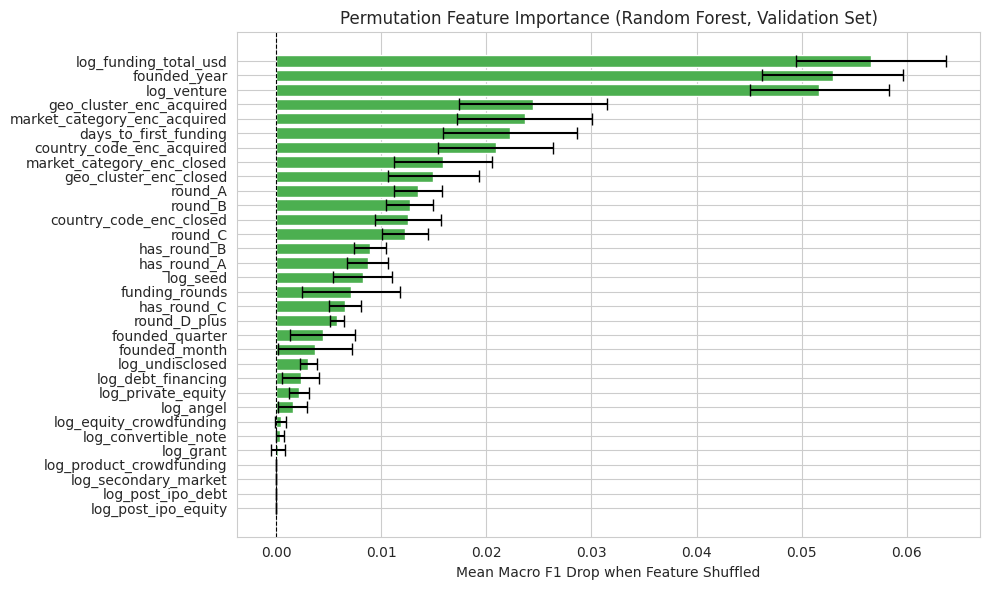

In [17]:
pfi_sorted = pfi_df.sort_values('PFI Mean', ascending=True)
bar_colors = ['#4CAF50' if v > 0 else '#FF5722' for v in pfi_sorted['PFI Mean']]

plt.figure(figsize=(10, 6))
plt.barh(pfi_sorted['Feature'], pfi_sorted['PFI Mean'],
         xerr=pfi_sorted['PFI Std'], color=bar_colors, edgecolor='white', capsize=4)
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Permutation Feature Importance (Random Forest, Validation Set)', fontsize=12)
plt.xlabel('Mean Macro F1 Drop when Feature Shuffled')
plt.tight_layout()
plt.show()

## 8. Feature Selection Voting — Aggregated Results

We combine all selection signals into a single vote table.  
Features consistently selected across multiple methods are the most reliable.

In [18]:
selection_df = pd.DataFrame({
    'Feature':       X_train.columns,
    'ANOVA':         anova_selected,
    'Lasso':         lasso_selected,
    'SVM':           svm_selected,
    'GradientBoost': gb_selected,
    'RandomForest':  rf_selected,
    'Ridge':         ridge_selected,
    'Forward':       forward_selected,
    #'PFI':           pfi_selected,
})

vote_cols = ['ANOVA', 'Lasso', 'SVM', 'GradientBoost', 'RandomForest', 'Ridge', 'Forward']
selection_df['Sum'] = selection_df[vote_cols].sum(axis=1)
selection_df = selection_df.sort_values('Sum', ascending=False).reset_index(drop=True)

display(selection_df)

,Feature,ANOVA,Lasso,SVM,GradientBoost,RandomForest,Ridge,Forward,Sum
0,funding_rounds,1,0,1,1,1,1,1,6
1,log_funding_total_usd,1,0,1,1,1,1,1,6
2,log_venture,1,0,1,1,1,1,1,6
3,founded_month,0,0,1,1,1,1,1,5
4,log_debt_financing,0,0,1,1,1,1,1,5
5,has_round_A,1,0,1,1,1,1,0,5
6,has_round_C,1,0,1,1,1,1,0,5
7,has_round_B,1,0,1,1,1,1,0,5
8,market_category_enc_closed,1,0,1,1,1,0,1,5
9,geo_cluster_enc_acquired,1,0,1,1,1,0,1,5


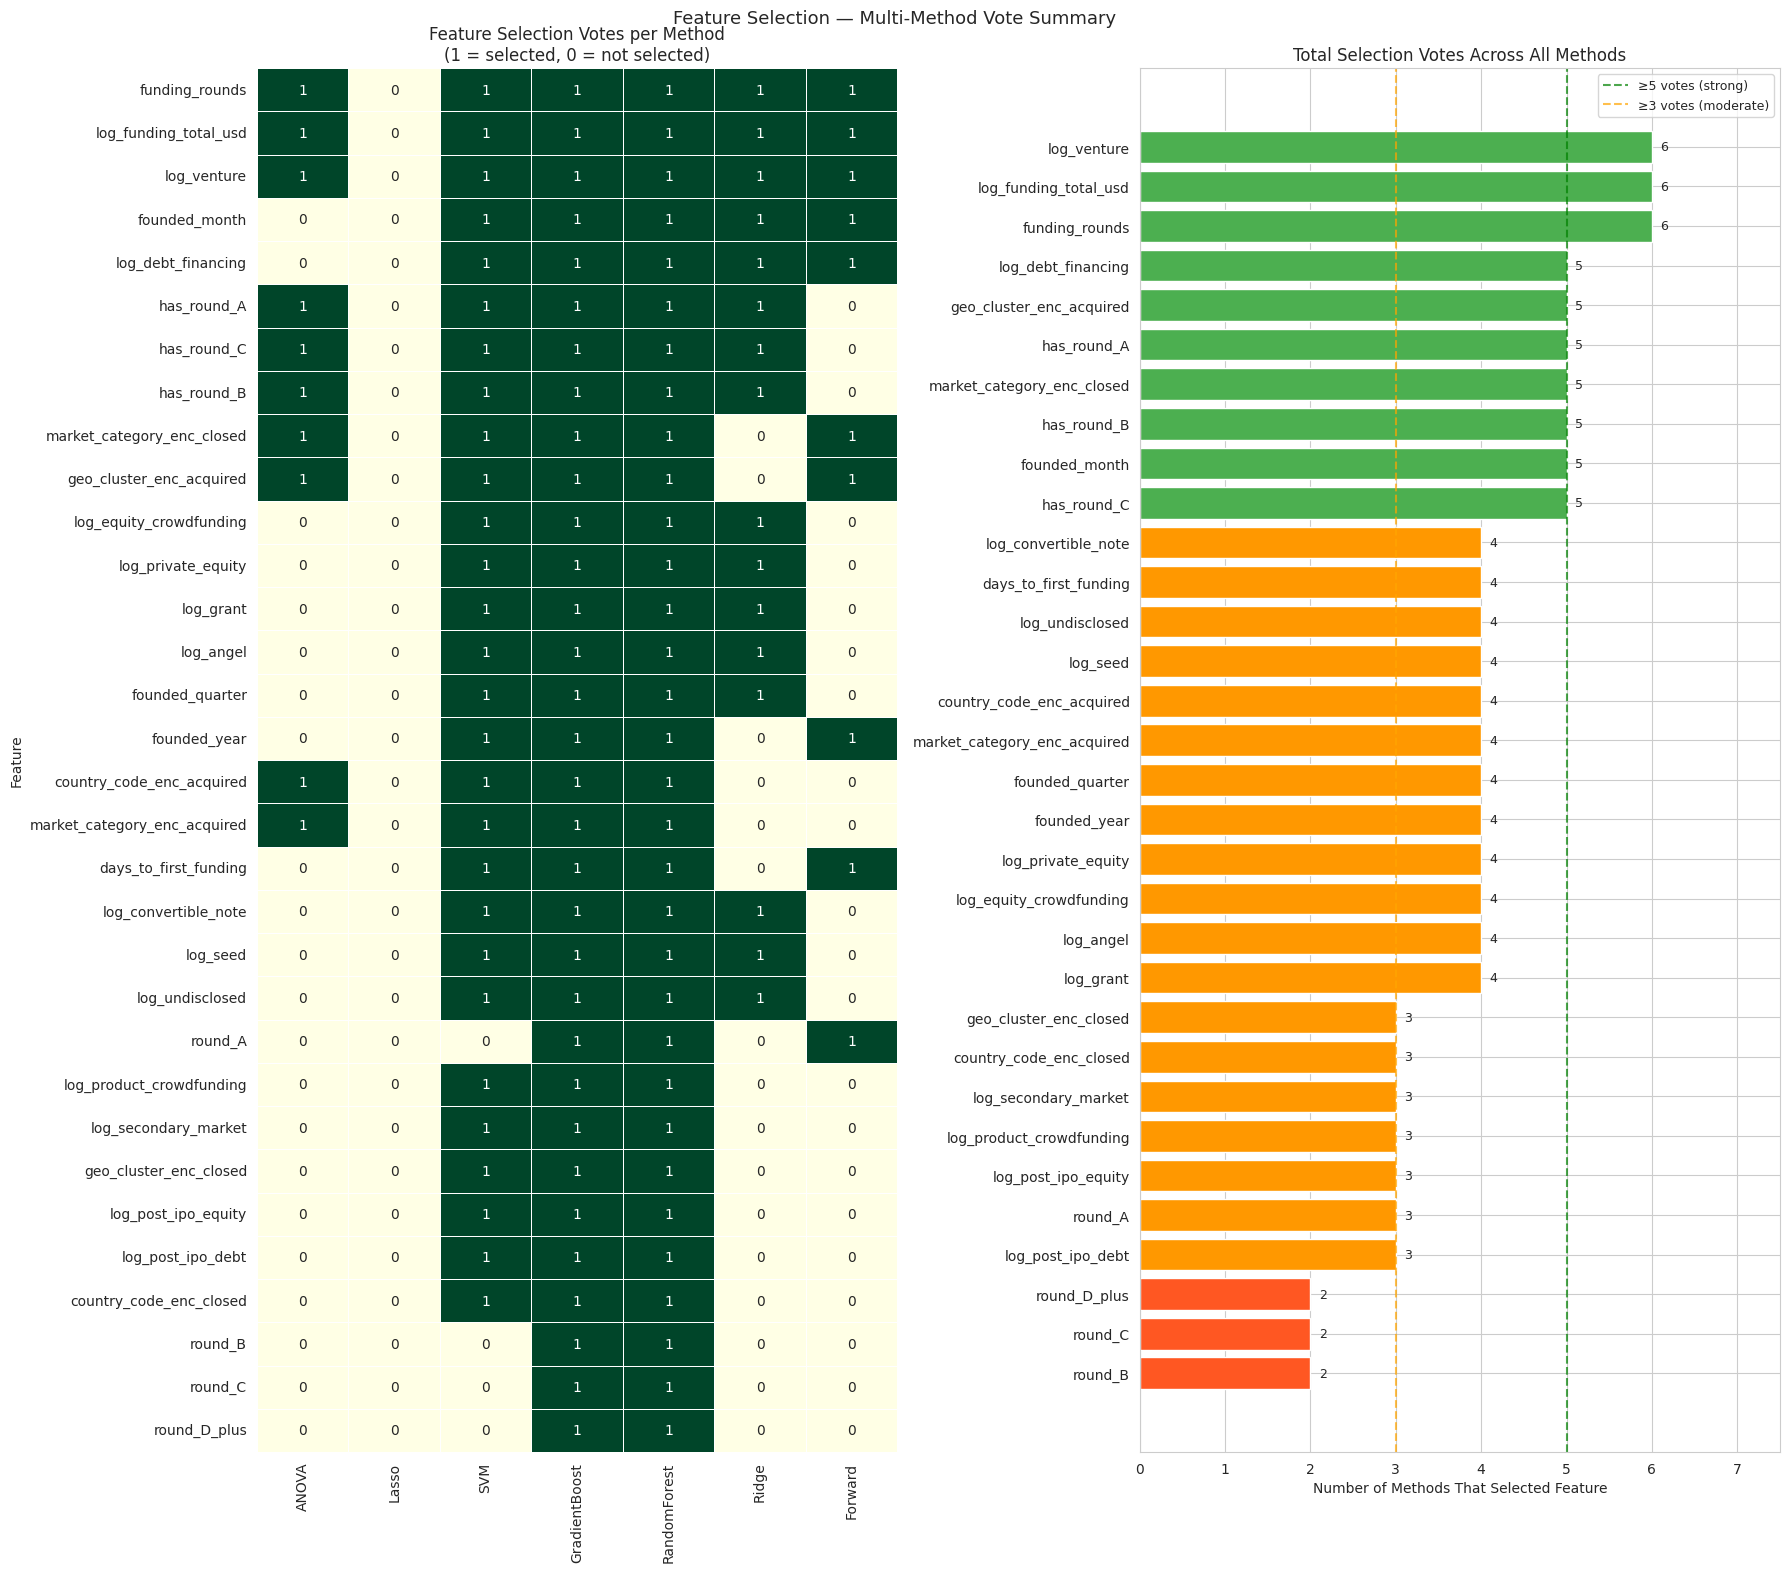

In [19]:
# Heatmap of selection votes
fig, axes = plt.subplots(1, 2, figsize=(18, max(6, len(X_train.columns) * 0.5)))

# Heatmap
heatmap_data = selection_df.set_index('Feature')[vote_cols]
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlGn',
            linewidths=0.5, ax=axes[0], cbar=False,
            vmin=0, vmax=1)
axes[0].set_title('Feature Selection Votes per Method\n(1 = selected, 0 = not selected)')
axes[0].set_xlabel('')

# Bar chart of total votes
sorted_sel = selection_df.sort_values('Sum', ascending=True)
bar_c = ['#4CAF50' if s >= 5 else '#FF9800' if s >= 3 else '#FF5722'
         for s in sorted_sel['Sum']]
axes[1].barh(sorted_sel['Feature'], sorted_sel['Sum'], color=bar_c, edgecolor='white')
axes[1].axvline(5, color='green',  linestyle='--', label='≥5 votes (strong)', alpha=0.7)
axes[1].axvline(3, color='orange', linestyle='--', label='≥3 votes (moderate)', alpha=0.7)
axes[1].set_title('Total Selection Votes Across All Methods')
axes[1].set_xlabel('Number of Methods That Selected Feature')
axes[1].set_xlim(0, len(vote_cols) + 0.5)
axes[1].legend(fontsize=9)
for i, v in enumerate(sorted_sel['Sum']):
    axes[1].text(v + 0.1, i, str(v), va='center', fontsize=9)

plt.suptitle('Feature Selection — Multi-Method Vote Summary', fontsize=13)
plt.tight_layout()
plt.show()

In [20]:
# Select features recommended by >= VOTE_THRESHOLD methods
VOTE_THRESHOLD = 5

selected_features = selection_df[selection_df['Sum'] >= VOTE_THRESHOLD]['Feature'].tolist()
all_features      = X_train.columns.tolist()

print(f"Vote threshold: {VOTE_THRESHOLD} / {len(vote_cols)} methods")
print(f"Selected features ({len(selected_features)}): {selected_features}")
print(f"Dropped features  ({len(all_features) - len(selected_features)}): "
      f"{[f for f in all_features if f not in selected_features]}")

# Build filtered datasets
X_train_sel = X_train[selected_features]
X_val_sel   = X_val[selected_features]
X_test_sel  = X_test[selected_features]

Vote threshold: 5 / 7 methods
Selected features (10): ['funding_rounds', 'log_funding_total_usd', 'log_venture', 'founded_month', 'log_debt_financing', 'has_round_A', 'has_round_C', 'has_round_B', 'market_category_enc_closed', 'geo_cluster_enc_acquired']
Dropped features  (22): ['round_A', 'round_B', 'round_C', 'founded_year', 'founded_quarter', 'log_seed', 'log_angel', 'log_grant', 'log_private_equity', 'log_equity_crowdfunding', 'log_convertible_note', 'log_undisclosed', 'log_product_crowdfunding', 'log_post_ipo_equity', 'log_post_ipo_debt', 'log_secondary_market', 'round_D_plus', 'days_to_first_funding', 'market_category_enc_acquired', 'geo_cluster_enc_closed', 'country_code_enc_acquired', 'country_code_enc_closed']


> **→ Modeling Decision:** Features selected by ≥ 5 of 8 methods form our **selected feature set**. We will compare models trained on the **full feature set** vs the **selected feature set** to confirm the selection improves or maintains performance.

---
# Part B — Modeling with Regularization

We train five model families on **each of the four resampling datasets** produced by `04_Imbalanced_Data.ipynb`:

| File | Technique |
|------|-----------|
| `train_resampled_ros.csv` | Random Over-Sampling |
| `train_resampled_rus.csv` | Random Under-Sampling |
| `train_resampled_smote.csv` | SMOTE |
| `train_resampled_smotetomek.csv` | SMOTETomek |

For every combination we record **Accuracy, Macro F1, Weighted F1, Precision, Recall, and per-class F1/Precision/Recall** on the validation set.
The baseline (no resampling) is excluded from model training but included as a reference line in the comparison charts.

All models use the **selected feature set** from Part A.

## 9. Define Models & Resampling Files

In [21]:
RESAMPLE_FILES = {
    'ROS':        'data/train_resampled_ros.csv',
    'RUS':        'data/train_resampled_rus.csv',
    'SMOTE':      'data/train_resampled_smote.csv',
    'SMOTETomek': 'data/train_resampled_smotetomek.csv',
}

models = {
    'LR (L2)': LogisticRegression(
        penalty='l2', C=1.0, solver='lbfgs',
        multi_class='multinomial', max_iter=2000,
        random_state=RANDOM_STATE
    ),
    'LR (L1)': LogisticRegression(
        penalty='l1', C=0.5, solver='saga',
        multi_class='ovr', max_iter=2000,
        random_state=RANDOM_STATE
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=12,
        max_features='sqrt', min_samples_leaf=3,
        class_weight='balanced',
        random_state=RANDOM_STATE, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=300, max_depth=5,
        learning_rate=0.05, subsample=0.8,
        random_state=RANDOM_STATE
    ),
    'XGBoost': XGBClassifier(
        n_estimators=300, max_depth=5,
        learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0,
        eval_metric='mlogloss', verbosity=0,
        random_state=RANDOM_STATE
    ),
}

print(f"Resampling strategies : {list(RESAMPLE_FILES.keys())}")
print(f"Models                : {list(models.keys())}")
print(f"Total runs            : {len(RESAMPLE_FILES) * len(models)} (+ feature set on selected)")

Resampling strategies : ['ROS', 'RUS', 'SMOTE', 'SMOTETomek']
Models                : ['LR (L2)', 'LR (L1)', 'Random Forest', 'Gradient Boosting', 'XGBoost']
Total runs            : 20 (+ feature set on selected)


## 10. Extended Metrics Helper

We expand the metrics dict from Part A to include **per-class Precision and Recall** alongside F1,
giving a complete picture of where each model is trading off false positives vs false negatives.

In [22]:
def full_metrics(y_true, y_pred, model_name='', resample=''):
    """Comprehensive metrics dict — overall + per-class P / R / F1."""
    f1_per   = f1_score(y_true, y_pred, average=None, labels=[0, 1, 2], zero_division=0)
    prec_per = precision_score(y_true, y_pred, average=None, labels=[0, 1, 2], zero_division=0)
    rec_per  = recall_score(y_true, y_pred, average=None, labels=[0, 1, 2], zero_division=0)
    return {
        'Model':               model_name,
        'Resample':            resample,
        # ── Overall ──────────────────────────────────────────────────────
        'Accuracy':            accuracy_score(y_true, y_pred),
        'Macro F1':            f1_score(y_true, y_pred, average='macro',    zero_division=0),
        'Macro Precision':     precision_score(y_true, y_pred, average='macro',    zero_division=0),
        'Macro Recall':        recall_score(y_true, y_pred, average='macro',       zero_division=0),
        'Weighted F1':         f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'Weighted Precision':  precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'Weighted Recall':     recall_score(y_true, y_pred, average='weighted',    zero_division=0),
        # ── Per class ────────────────────────────────────────────────────
        'F1 closed':           f1_per[0],
        'Prec closed':         prec_per[0],
        'Rec closed':          rec_per[0],
        'F1 operating':        f1_per[1],
        'Prec operating':      prec_per[1],
        'Rec operating':       rec_per[1],
        'F1 acquired':         f1_per[2],
        'Prec acquired':       prec_per[2],
        'Rec acquired':        rec_per[2],
    }

print("full_metrics() defined — columns:",
      [k for k in full_metrics([0],[0]).keys()])

full_metrics() defined — columns: ['Model', 'Resample', 'Accuracy', 'Macro F1', 'Macro Precision', 'Macro Recall', 'Weighted F1', 'Weighted Precision', 'Weighted Recall', 'F1 closed', 'Prec closed', 'Rec closed', 'F1 operating', 'Prec operating', 'Rec operating', 'F1 acquired', 'Prec acquired', 'Rec acquired']


## 11. Train All Models × All Resampling Strategies

Each model is trained on the **selected feature set** from Part A.  
Val and test sets are never used during training or selection.

In [23]:
import copy

all_results  = []   # list of metrics dicts
fitted_store = {}   # key: (resample_name, model_name) → fitted model

for resample_name, filepath in RESAMPLE_FILES.items():
    train_r = pd.read_csv(filepath)
    X_tr = prepare_X(train_r)          # drop raw funding cols (geo_cluster/market/country already encoded & dropped by pipeline)
    X_tr = X_tr[selected_features]     # selected feature set from Part A
    y_tr = train_r['status_code']

    print(f"\n{'─'*60}")
    print(f" {resample_name}  —  train shape: {X_tr.shape}")
    print(f"{'─'*60}")

    for model_name, model in models.items():
        m = copy.deepcopy(model)
        m.fit(X_tr, y_tr)
        y_pred = m.predict(X_val_sel)

        metrics = full_metrics(y_val, y_pred,
                               model_name=model_name,
                               resample=resample_name)
        all_results.append(metrics)
        fitted_store[(resample_name, model_name)] = m

        print(f"  {model_name:20s}  "
              f"Macro F1={metrics['Macro F1']:.4f}  "
              f"Prec={metrics['Macro Precision']:.4f}  "
              f"Rec={metrics['Macro Recall']:.4f}")

results_df = pd.DataFrame(all_results)
print(f"\nTotal runs: {len(results_df)}")


────────────────────────────────────────────────────────────
 ROS  —  train shape: (72294, 10)
────────────────────────────────────────────────────────────
  LR (L2)               Macro F1=0.3406  Prec=0.3977  Rec=0.5228
  LR (L1)               Macro F1=0.3392  Prec=0.3969  Rec=0.5190
  Random Forest         Macro F1=0.3944  Prec=0.4069  Rec=0.5230
  Gradient Boosting     Macro F1=0.3826  Prec=0.4036  Rec=0.5211
  XGBoost               Macro F1=0.3761  Prec=0.4060  Rec=0.5381

────────────────────────────────────────────────────────────
 RUS  —  train shape: (4530, 10)
────────────────────────────────────────────────────────────
  LR (L2)               Macro F1=0.3193  Prec=0.3930  Rec=0.5172
  LR (L1)               Macro F1=0.3231  Prec=0.3943  Rec=0.5179
  Random Forest         Macro F1=0.3451  Prec=0.4017  Rec=0.5415
  Gradient Boosting     Macro F1=0.3450  Prec=0.3988  Rec=0.5235
  XGBoost               Macro F1=0.3475  Prec=0.4021  Rec=0.5365

────────────────────────────────────

## 12. Results Summary Table

Sorted by **Macro F1** — our primary selection criterion.  
The table shows all overall metrics; per-class breakdown follows in Section 13.

In [24]:
summary_cols = ['Model', 'Resample', 'Accuracy',
                'Macro F1', 'Macro Precision', 'Macro Recall',
                'Weighted F1', 'Weighted Precision', 'Weighted Recall']

summary_df = results_df[summary_cols].sort_values('Macro F1', ascending=False).reset_index(drop=True)
display(summary_df.round(4))

,Model,Resample,Accuracy,Macro F1,Macro Precision,Macro Recall,Weighted F1,Weighted Precision,Weighted Recall
0,Random Forest,SMOTETomek,0.7372,0.4189,0.4083,0.4453,0.7626,0.7944,0.7372
1,Random Forest,SMOTE,0.7436,0.4148,0.4057,0.4355,0.7657,0.7923,0.7436
2,Random Forest,ROS,0.5838,0.3944,0.4069,0.5230,0.6582,0.8164,0.5838
3,XGBoost,SMOTETomek,0.8468,0.3886,0.4324,0.3806,0.8128,0.7899,0.8468
4,Gradient Boosting,ROS,0.5592,0.3826,0.4036,0.5211,0.6378,0.8184,0.5592
5,XGBoost,SMOTE,0.8488,0.3806,0.4384,0.3733,0.8116,0.7888,0.8488
6,XGBoost,ROS,0.5297,0.3761,0.4060,0.5381,0.6116,0.8225,0.5297
7,Gradient Boosting,SMOTETomek,0.8531,0.3716,0.4389,0.3677,0.8117,0.7879,0.8531
8,Gradient Boosting,SMOTE,0.8548,0.3661,0.4402,0.3633,0.8112,0.7876,0.8548
9,LR (L2),SMOTE,0.4807,0.3496,0.3981,0.5205,0.5680,0.8217,0.4807


In [25]:
# ── Save full results to CSV so you can inspect and choose your manual model ──
import os
os.makedirs('results', exist_ok=True)
results_df.to_csv('results/model_comparison.csv', index=False)
print("Saved → results/model_comparison.csv")
print("Open this file, pick your preferred (Model, Resample) combination,")
print("then set MANUAL_MODEL and MANUAL_RESAMPLE in Section 15.")


Saved → results/model_comparison.csv
Open this file, pick your preferred (Model, Resample) combination,
then set MANUAL_MODEL and MANUAL_RESAMPLE in Section 15.


## 13. Per-Class Metrics Breakdown

Precision, Recall, and F1 for each class — sorted by Macro F1.  
**Key tradeoff to watch:** high Recall on *closed* / *acquired* vs acceptable Precision.  
A model that improves minority recall but tanks precision is just predicting those classes more recklessly.

In [26]:
per_class_cols = ['Model', 'Resample',
                  'Prec closed',   'Rec closed',   'F1 closed',
                  'Prec operating','Rec operating','F1 operating',
                  'Prec acquired', 'Rec acquired', 'F1 acquired']

per_class_df = results_df[per_class_cols].sort_values(
    ['F1 closed', 'F1 acquired'], ascending=False
).reset_index(drop=True)

display(per_class_df.round(4))

,Model,Resample,Prec closed,Rec closed,F1 closed,Prec operating,Rec operating,F1 operating,Prec acquired,Rec acquired,F1 acquired
0,Random Forest,ROS,0.1094,0.3951,0.1714,0.9191,0.5962,0.7233,0.1923,0.5776,0.2885
1,Random Forest,RUS,0.1006,0.4907,0.1669,0.9344,0.4361,0.5947,0.1702,0.6977,0.2737
2,XGBoost,ROS,0.1023,0.4321,0.1654,0.9270,0.5238,0.6694,0.1888,0.6584,0.2935
3,Gradient Boosting,ROS,0.1011,0.3735,0.1591,0.9225,0.5647,0.7005,0.1872,0.6253,0.2882
4,XGBoost,RUS,0.0941,0.4815,0.1575,0.9341,0.4448,0.6026,0.1779,0.6832,0.2823
5,LR (L2),SMOTE,0.0912,0.4444,0.1513,0.9280,0.4671,0.6214,0.1751,0.6501,0.2759
6,LR (L1),SMOTETomek,0.0898,0.4630,0.1504,0.9302,0.4466,0.6034,0.1741,0.6563,0.2752
7,LR (L2),ROS,0.0898,0.4599,0.1503,0.9307,0.4398,0.5973,0.1725,0.6687,0.2743
8,LR (L1),SMOTE,0.0903,0.4383,0.1497,0.9270,0.4669,0.6210,0.1753,0.6522,0.2763
9,Gradient Boosting,RUS,0.0883,0.4475,0.1474,0.9307,0.4500,0.6067,0.1775,0.6729,0.2809


## 14. Visual Comparison

### 14.1 Macro Metrics by Model × Resampling Strategy

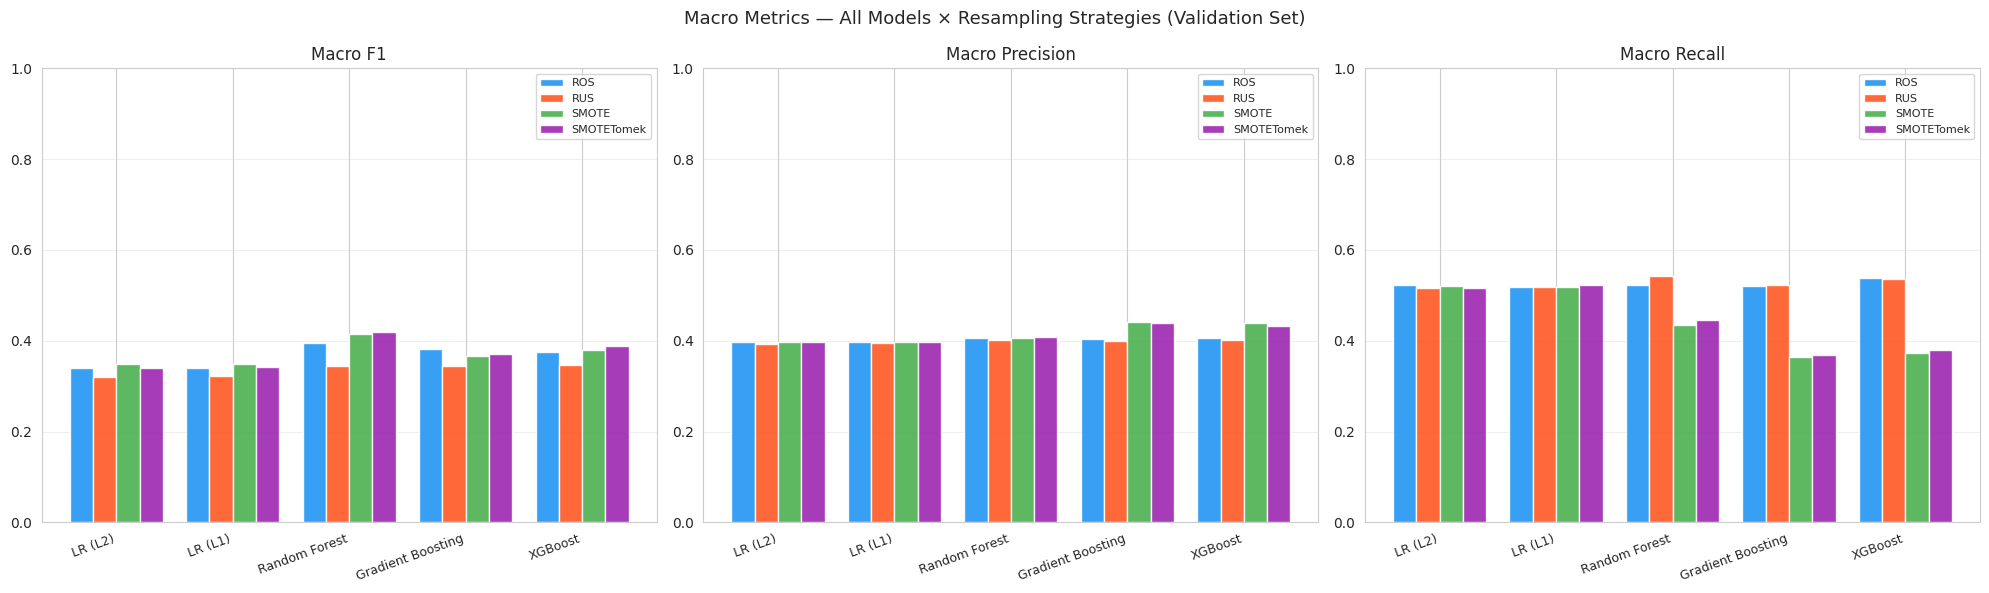

In [27]:
macro_metrics = ['Macro F1', 'Macro Precision', 'Macro Recall']
resample_colors = {'ROS': '#2196F3', 'RUS': '#FF5722',
                   'SMOTE': '#4CAF50', 'SMOTETomek': '#9C27B0'}
model_names = list(models.keys())
x = np.arange(len(model_names))
width = 0.2

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, metric in zip(axes, macro_metrics):
    for i, (resample, color) in enumerate(resample_colors.items()):
        vals = [results_df[(results_df['Model'] == m) &
                           (results_df['Resample'] == resample)][metric].values[0]
                for m in model_names]
        bars = ax.bar(x + i * width, vals, width, label=resample,
                      color=color, edgecolor='white', alpha=0.9)
    ax.set_title(metric, fontsize=12)
    ax.set_xticks(x + width * 1.5)
    ax.set_xticklabels(model_names, rotation=20, ha='right', fontsize=9)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Macro Metrics — All Models × Resampling Strategies (Validation Set)', fontsize=13)
plt.tight_layout()
plt.show()

### 14.2 Per-Class F1 Heatmap — All Combinations

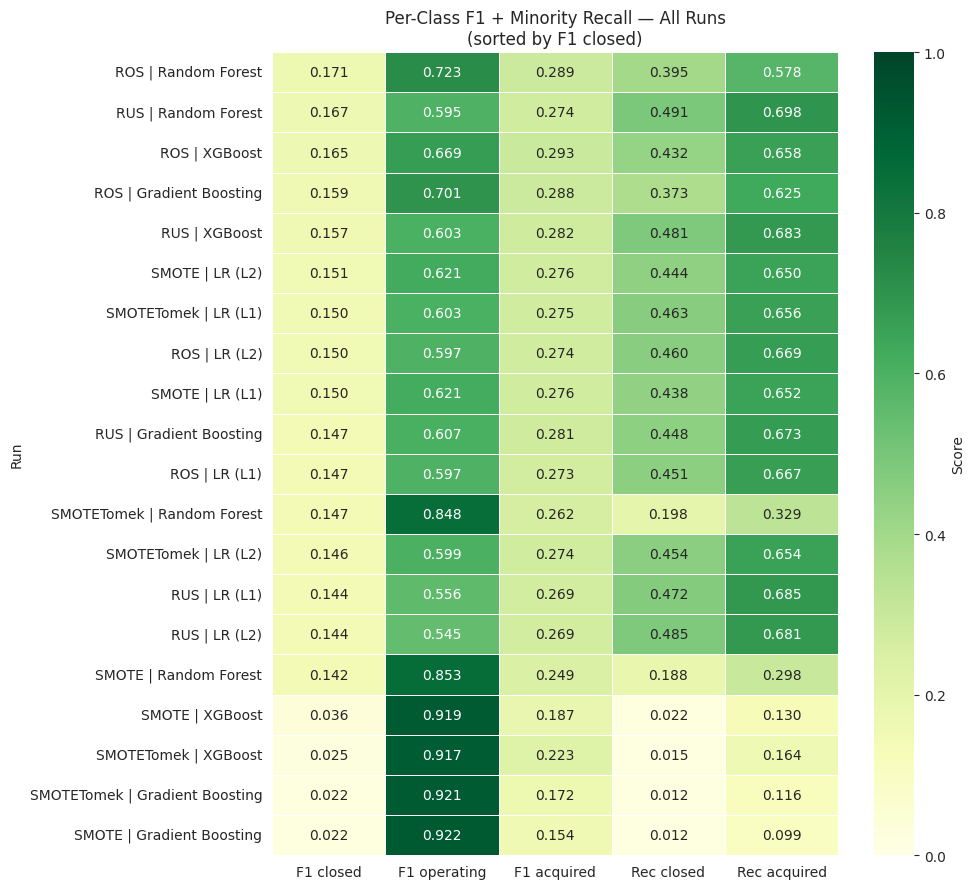

In [28]:
# Build a combined label for each run
results_df['Run'] = results_df['Resample'] + ' | ' + results_df['Model']

heatmap_data = results_df.set_index('Run')[['F1 closed', 'F1 operating', 'F1 acquired',
                                              'Rec closed', 'Rec acquired']]\
                          .sort_values('F1 closed', ascending=False)

fig, ax = plt.subplots(figsize=(10, max(8, len(heatmap_data) * 0.45)))
sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='YlGn',
            linewidths=0.5, ax=ax, vmin=0, vmax=1,
            cbar_kws={'label': 'Score'})
ax.set_title('Per-Class F1 + Minority Recall — All Runs\n(sorted by F1 closed)', fontsize=12)
ax.set_xlabel('')
plt.tight_layout()
plt.show()

### 14.3 Precision vs Recall Trade-off — Minority Classes

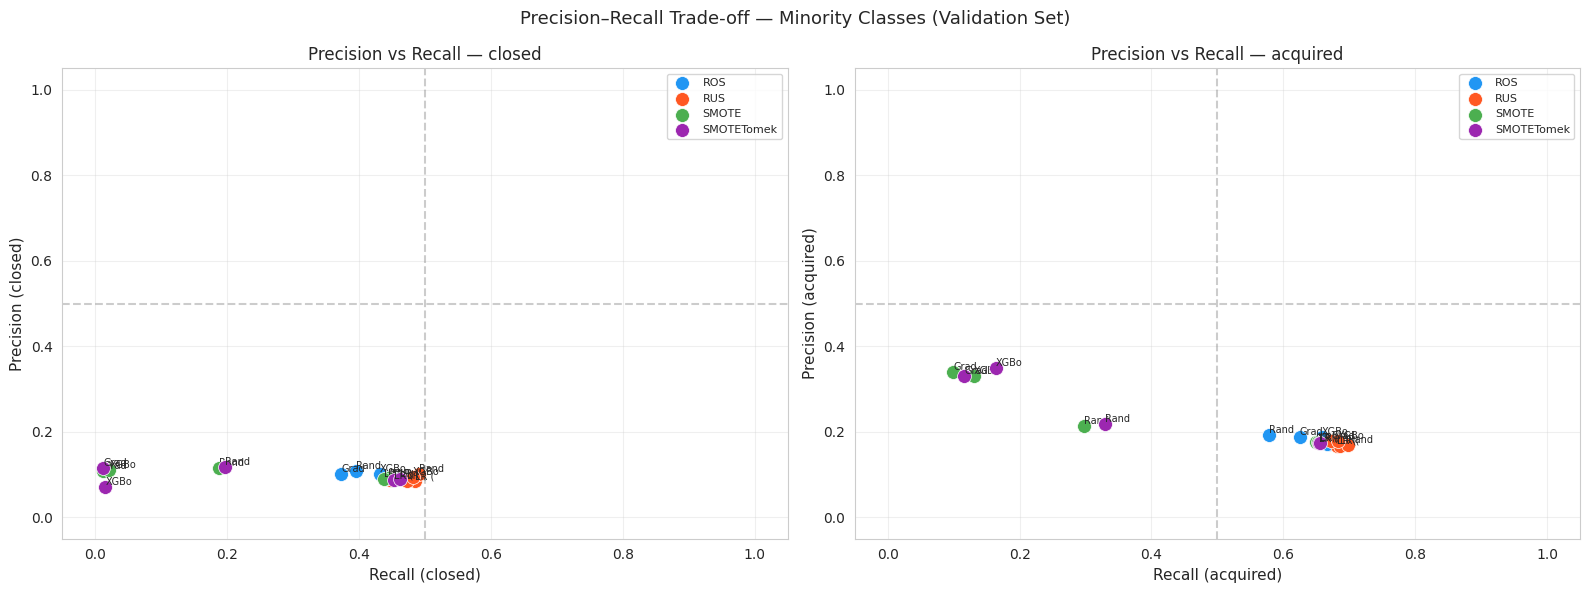

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (cls, prec_col, rec_col) in zip(axes, [
    ('closed',   'Prec closed',   'Rec closed'),
    ('acquired', 'Prec acquired', 'Rec acquired'),
]):
    for resample, color in resample_colors.items():
        sub = results_df[results_df['Resample'] == resample]
        ax.scatter(sub[rec_col], sub[prec_col],
                   c=color, label=resample, s=100, edgecolors='white', linewidth=0.5, zorder=3)
        for _, row in sub.iterrows():
            ax.annotate(row['Model'][:4],  # first 4 chars to keep labels short
                        (row[rec_col], row[prec_col]),
                        fontsize=7, ha='left', va='bottom')
    ax.set_xlabel(f'Recall ({cls})', fontsize=11)
    ax.set_ylabel(f'Precision ({cls})', fontsize=11)
    ax.set_title(f'Precision vs Recall — {cls}', fontsize=12)
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.axhline(0.5, color='grey', linestyle='--', alpha=0.4)
    ax.axvline(0.5, color='grey', linestyle='--', alpha=0.4)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Precision–Recall Trade-off — Minority Classes (Validation Set)', fontsize=13)
plt.tight_layout()
plt.show()

## 15. Model Selection & Regularization Sweep

We evaluate **two candidates** in parallel:

| Candidate | How it's chosen |
|-----------|----------------|
| **Auto-best** | Highest Macro F1 in `results_df` (Section 12) |
| **Manual** | Set `MANUAL_MODEL` + `MANUAL_RESAMPLE` below after reviewing `results/model_comparison.csv` |

Each candidate gets its own regularization sweep. The **final model for test evaluation**
is controlled by `FINAL_MODEL_CHOICE` at the bottom of this section — set it to
`'auto'` or `'manual'` before running Section 19.

> **Workflow:** Run Section 12 → open `results/model_comparison.csv` → fill in
> `MANUAL_MODEL` and `MANUAL_RESAMPLE` below → run this section → set `FINAL_MODEL_CHOICE`.

Auto-best  : Random Forest + SMOTETomek  Acc=0.7372  Macro F1=0.4189
Manual     : Random Forest + ROS  Acc=0.5838  Macro F1=0.3944
Final choice for test: MANUAL

────────────────────────────────────────────────────────────
 Regularization sweep — Auto-best: Random Forest + SMOTETomek
────────────────────────────────────────────────────────────

────────────────────────────────────────────────────────────
 Regularization sweep — Manual: Random Forest + ROS
────────────────────────────────────────────────────────────


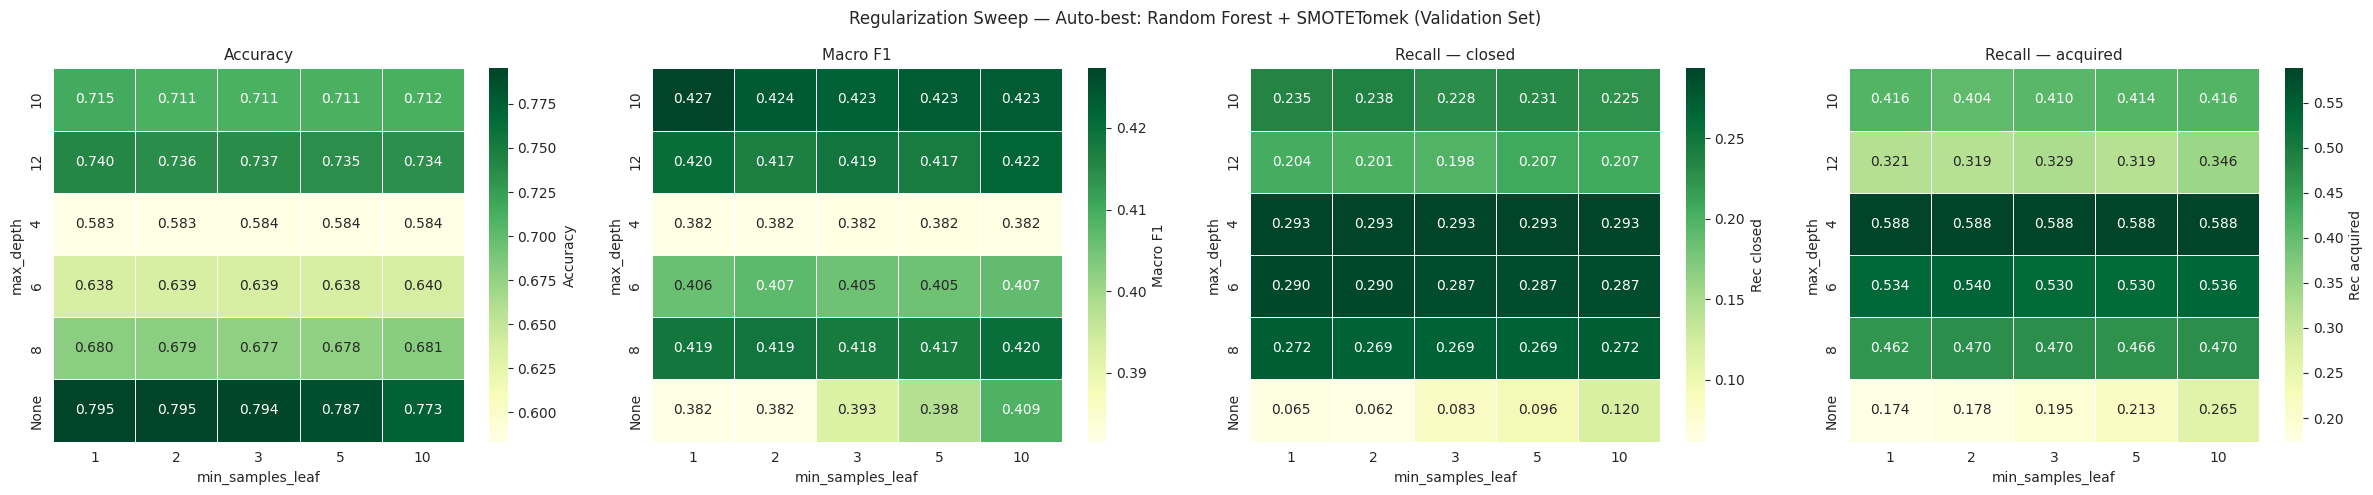

  Best: max_depth=10, min_samples_leaf=1  →  Acc=0.7153  Macro F1=0.4273


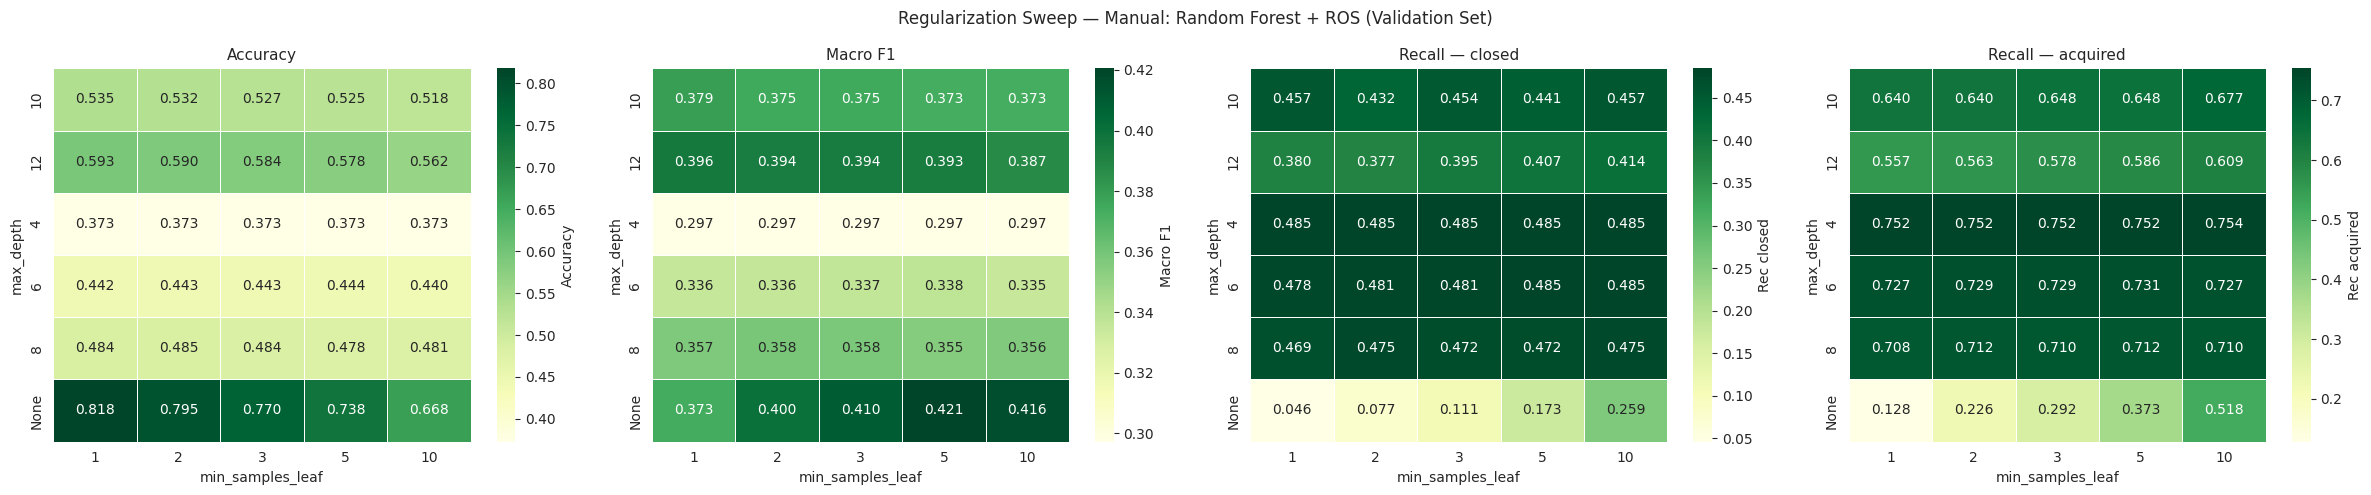

  Best: max_depth=None, min_samples_leaf=5  →  Acc=0.7379  Macro F1=0.4205


In [40]:
import copy

# ╔══════════════════════════════════════════════════════════════════════╗
# ║  USER CONFIGURATION — fill in after reviewing model_comparison.csv  ║
# ╚══════════════════════════════════════════════════════════════════════╝
MANUAL_MODEL    = 'Random Forest'   # e.g. 'Random Forest', 'XGBoost', 'LR (L2)'
MANUAL_RESAMPLE = 'ROS'           # e.g. 'ROS', 'RUS', 'SMOTE', 'SMOTETomek'

# Set to 'auto' or 'manual' — this controls which model runs on the test set
FINAL_MODEL_CHOICE = 'manual'

# ── Identify auto-best ────────────────────────────────────────────────────
auto_row      = results_df.loc[results_df['Macro F1'].idxmax()]
auto_resample = auto_row['Resample']
auto_model    = auto_row['Model']
auto_fitted   = fitted_store[(auto_resample, auto_model)]

# ── Validate manual choice ────────────────────────────────────────────────
assert (MANUAL_RESAMPLE, MANUAL_MODEL) in fitted_store, (
    f"({MANUAL_RESAMPLE!r}, {MANUAL_MODEL!r}) not found in fitted_store. "
    f"Check spelling against results/model_comparison.csv"
)
manual_row     = results_df[(results_df['Model'] == MANUAL_MODEL) &
                             (results_df['Resample'] == MANUAL_RESAMPLE)].iloc[0]
manual_fitted  = fitted_store[(MANUAL_RESAMPLE, MANUAL_MODEL)]

print("Auto-best  :", auto_model,   "+", auto_resample,
      f" Acc={auto_row['Accuracy']:.4f}  Macro F1={auto_row['Macro F1']:.4f}")
print("Manual     :", MANUAL_MODEL, "+", MANUAL_RESAMPLE,
      f" Acc={manual_row['Accuracy']:.4f}  Macro F1={manual_row['Macro F1']:.4f}")
print(f"Final choice for test: {FINAL_MODEL_CHOICE.upper()}")


# ════════════════════════════════════════════════════════════════════════════
# Regularization sweep — runs for BOTH candidates
# ════════════════════════════════════════════════════════════════════════════
def reg_sweep(model_name, resample_name, label):
    """Run regularization sweep and return (reg_df, row_key, col_key)."""
    print(f"\n{'─'*60}")
    print(f" Regularization sweep — {label}: {model_name} + {resample_name}")
    print(f"{'─'*60}")

    train_s = pd.read_csv(RESAMPLE_FILES[resample_name])
    X_tr_s  = prepare_X(train_s)[selected_features]
    y_tr_s  = train_s['status_code']

    results_s = []

    if model_name == 'Random Forest':
        max_depths        = [4, 6, 8, 10, 12, None]
        min_samples_leafs = [1, 2, 3, 5, 10]
        for md_val in max_depths:
            for msl in min_samples_leafs:
                m = RandomForestClassifier(
                    n_estimators=300, max_features='sqrt',
                    class_weight='balanced',
                    max_depth=md_val, min_samples_leaf=msl,
                    random_state=RANDOM_STATE, n_jobs=-1
                )
                m.fit(X_tr_s, y_tr_s)
                y_pred = m.predict(X_val_sel)
                results_s.append({
                    'max_depth':        str(md_val) if md_val is not None else 'None',
                    'min_samples_leaf': msl,
                    'Accuracy':         accuracy_score(y_val, y_pred),
                    'Macro F1':         f1_score(y_val, y_pred, average='macro', zero_division=0),
                    'Rec closed':       recall_score(y_val, y_pred, average=None, labels=[0,1,2], zero_division=0)[0],
                    'Rec acquired':     recall_score(y_val, y_pred, average=None, labels=[0,1,2], zero_division=0)[2],
                })
        rdf = pd.DataFrame(results_s)
        return rdf, 'max_depth', 'min_samples_leaf'

    elif model_name in ('XGBoost', 'Gradient Boosting'):
        alphas  = [0, 0.01, 0.1, 0.5, 1.0, 2.0]
        lambdas = [0.1, 0.5, 1.0, 2.0, 5.0]
        for alpha in alphas:
            for lam in lambdas:
                m = (XGBClassifier(
                        n_estimators=200, max_depth=5, learning_rate=0.05,
                        subsample=0.8, colsample_bytree=0.8,
                        reg_alpha=alpha, reg_lambda=lam,
                        eval_metric='mlogloss', verbosity=0, random_state=RANDOM_STATE)
                     if model_name == 'XGBoost' else
                     GradientBoostingClassifier(
                        n_estimators=200, max_depth=5, learning_rate=0.05,
                        subsample=0.8, random_state=RANDOM_STATE))
                m.fit(X_tr_s, y_tr_s)
                y_pred = m.predict(X_val_sel)
                results_s.append({
                    'reg_alpha':    alpha, 'reg_lambda': lam,
                    'Accuracy':     accuracy_score(y_val, y_pred),
                    'Macro F1':     f1_score(y_val, y_pred, average='macro', zero_division=0),
                    'Rec closed':   recall_score(y_val, y_pred, average=None, labels=[0,1,2], zero_division=0)[0],
                    'Rec acquired': recall_score(y_val, y_pred, average=None, labels=[0,1,2], zero_division=0)[2],
                })
        rdf = pd.DataFrame(results_s)
        return rdf, 'reg_alpha', 'reg_lambda'

    elif 'LR' in model_name:
        C_values = [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0]
        penalty  = 'l1' if 'L1' in model_name else 'l2'
        solver   = 'saga' if penalty == 'l1' else 'lbfgs'
        for C in C_values:
            m = LogisticRegression(penalty=penalty, C=C, solver=solver,
                                   multi_class='ovr', max_iter=2000,
                                   random_state=RANDOM_STATE)
            m.fit(X_tr_s, y_tr_s)
            y_pred = m.predict(X_val_sel)
            results_s.append({
                'C':            C,
                'Accuracy':     accuracy_score(y_val, y_pred),
                'Macro F1':     f1_score(y_val, y_pred, average='macro', zero_division=0),
                'Rec closed':   recall_score(y_val, y_pred, average=None, labels=[0,1,2], zero_division=0)[0],
                'Rec acquired': recall_score(y_val, y_pred, average=None, labels=[0,1,2], zero_division=0)[2],
            })
        rdf = pd.DataFrame(results_s).set_index('C')
        rdf.plot(kind='bar', figsize=(12, 5),
                 color=['#FF9800','#2196F3','#FF5722','#4CAF50'], edgecolor='white')
        plt.title(f'Regularization Sweep — {label}: {model_name} ({resample_name})', fontsize=12)
        plt.xlabel('C (inverse regularization strength)')
        plt.xticks(rotation=0)
        plt.tight_layout()
        plt.show()
        best_C = rdf['Macro F1'].idxmax()
        print(f"Best C={best_C}  →  Macro F1={rdf.loc[best_C,'Macro F1']:.4f}")
        return None, None, None   # no heatmap for LR

    return None, None, None


def plot_sweep_heatmaps(rdf, row_key, col_key, label):
    """Plot Macro F1, Rec-closed, Rec-acquired heatmaps for a sweep result."""
    if rdf is None or row_key not in rdf.columns:
        return
    fig, axes = plt.subplots(1, 4, figsize=(24, 5))
    for ax, metric, title in zip(axes,
        ['Accuracy', 'Macro F1', 'Rec closed', 'Rec acquired'],
        ['Accuracy', 'Macro F1', 'Recall — closed', 'Recall — acquired']):
        pivot = rdf.pivot(index=row_key, columns=col_key, values=metric)
        sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlGn', linewidths=0.5,
                    ax=ax, cbar_kws={'label': metric})
        ax.set_title(title, fontsize=11)
        ax.set_xlabel(col_key)
        ax.set_ylabel(row_key)
    plt.suptitle(f'Regularization Sweep — {label} (Validation Set)', fontsize=12)
    plt.tight_layout()
    plt.show()
    best = rdf.loc[rdf['Macro F1'].idxmax()]
    print(f"  Best: {row_key}={best[row_key]}, {col_key}={best[col_key]}"
          f"  →  Acc={best['Accuracy']:.4f}  Macro F1={best['Macro F1']:.4f}")


# ── Run sweeps ────────────────────────────────────────────────────────────
auto_reg_df, auto_rk, auto_ck     = reg_sweep(auto_model,   auto_resample,   'Auto-best')
manual_reg_df, manual_rk, manual_ck = reg_sweep(MANUAL_MODEL, MANUAL_RESAMPLE, 'Manual')

plot_sweep_heatmaps(auto_reg_df,   auto_rk,   auto_ck,   f'Auto-best: {auto_model} + {auto_resample}')
plot_sweep_heatmaps(manual_reg_df, manual_rk, manual_ck, f'Manual: {MANUAL_MODEL} + {MANUAL_RESAMPLE}')


## 16. Side-by-Side Comparison — Auto-best vs Manual

Confusion matrices and key metrics for both candidates on the validation set.
Use this to confirm your `FINAL_MODEL_CHOICE` before running the test set in Section 19.

,Candidate,Model,Resample,Accuracy,Macro F1,Macro Precision,Macro Recall,Rec closed,Rec acquired,F1 closed,F1 acquired
0,Auto-best,Random Forest,SMOTETomek,0.7372,0.4189,0.4083,0.4453,0.1975,0.3292,0.1468,0.2617
1,Manual,Random Forest,ROS,0.5838,0.3944,0.4069,0.5230,0.3951,0.5776,0.1714,0.2885


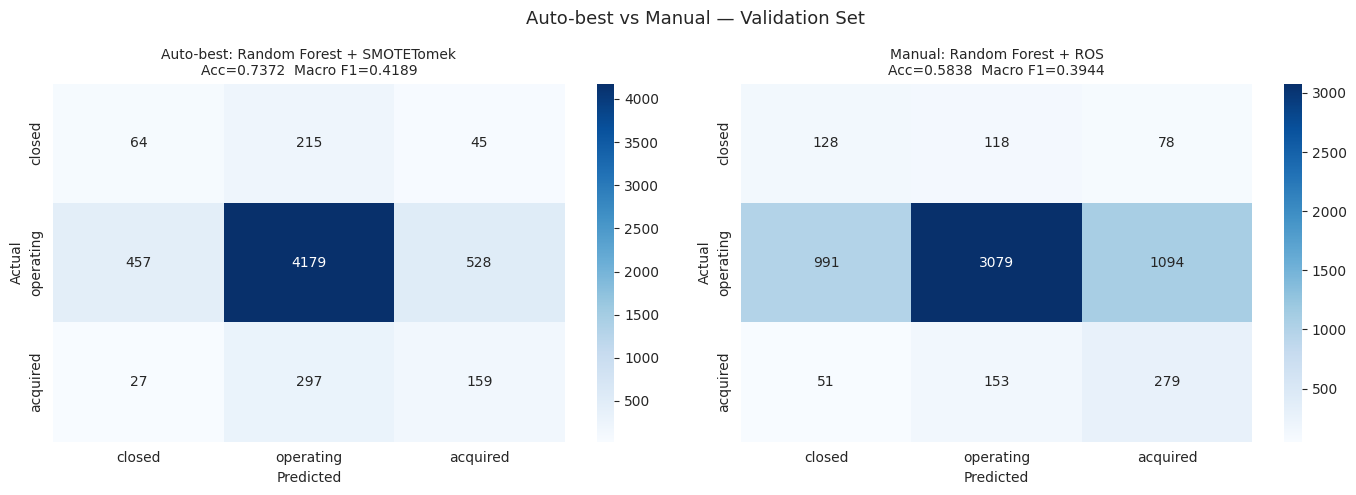


FINAL_MODEL_CHOICE is currently set to: 'MANUAL'
  → Test set will run on: Random Forest + ROS
Change FINAL_MODEL_CHOICE in Section 15 if needed, then re-run from there.


In [41]:
# ── Key metrics side by side ─────────────────────────────────────────────
compare_candidates = pd.DataFrame([
    full_metrics(y_val, auto_fitted.predict(X_val_sel),
                 model_name=auto_model,   resample=auto_resample),
    full_metrics(y_val, manual_fitted.predict(X_val_sel),
                 model_name=MANUAL_MODEL, resample=MANUAL_RESAMPLE),
])
compare_candidates.insert(0, 'Candidate', ['Auto-best', 'Manual'])

display_cols = ['Candidate', 'Model', 'Resample', 'Accuracy',
                 'Macro F1', 'Macro Precision', 'Macro Recall',
                 'Rec closed', 'Rec acquired', 'F1 closed', 'F1 acquired']
display(compare_candidates[display_cols].round(4))

# ── Confusion matrices ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (label, fitted, row) in zip(axes, [
    ('Auto-best',  auto_fitted,   auto_row),
    ('Manual',     manual_fitted, manual_row),
]):
    y_pred = fitted.predict(X_val_sel)
    cm = confusion_matrix(y_val, y_pred, labels=[0, 1, 2])
    acc = accuracy_score(y_val, y_pred)
    f1  = f1_score(y_val, y_pred, average='macro', zero_division=0)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=STATUS_NAMES, yticklabels=STATUS_NAMES)
    model_label = row['Model'] if hasattr(row, '__getitem__') else str(row)
    ax.set_title(f"{label}: {row['Model']} + {row['Resample']}\n"
                 f"Acc={acc:.4f}  Macro F1={f1:.4f}", fontsize=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Auto-best vs Manual — Validation Set', fontsize=13)
plt.tight_layout()
plt.show()

print(f"\nFINAL_MODEL_CHOICE is currently set to: '{FINAL_MODEL_CHOICE.upper()}'")
print(f"  → Test set will run on: "
      f"{(auto_model + ' + ' + auto_resample) if FINAL_MODEL_CHOICE == 'auto' else (MANUAL_MODEL + ' + ' + MANUAL_RESAMPLE)}")
print("Change FINAL_MODEL_CHOICE in Section 15 if needed, then re-run from there.")


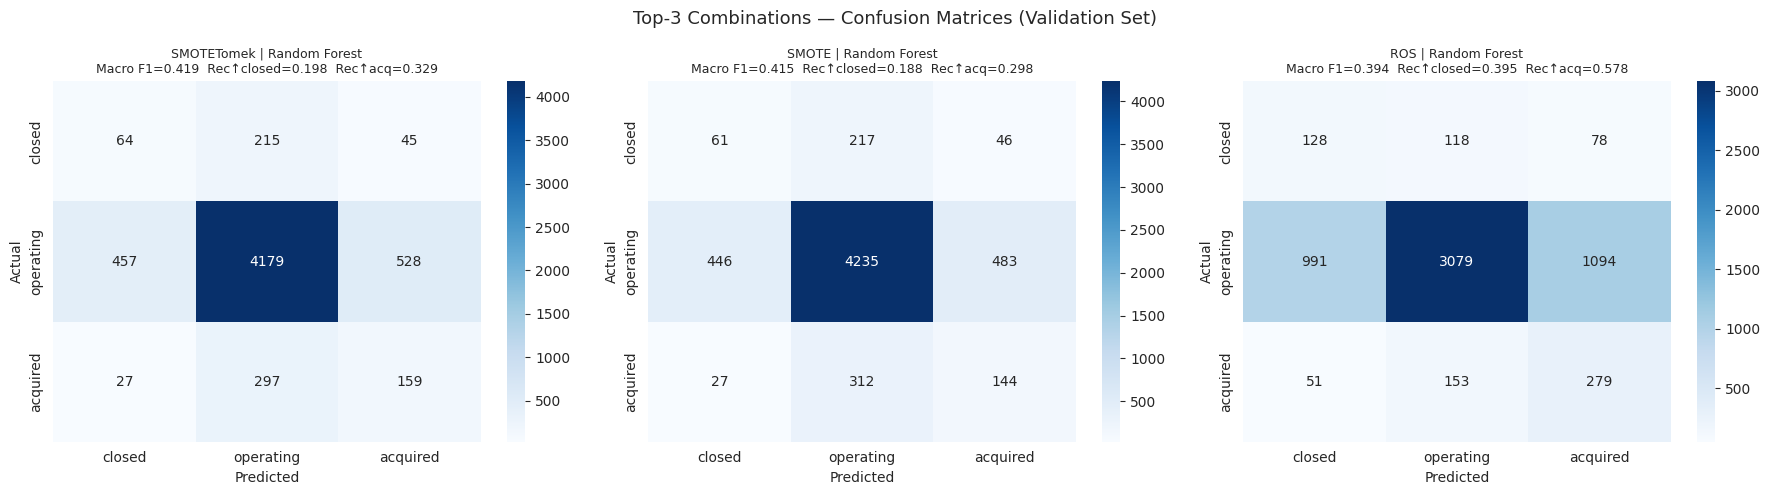

In [42]:
# Top-3 runs — confusion matrices side by side
top3_rows = results_df.sort_values('Macro F1', ascending=False).head(3)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (_, row) in zip(axes, top3_rows.iterrows()):
    key     = (row['Resample'], row['Model'])
    fitted  = fitted_store[key]
    y_pred  = fitted.predict(X_val_sel)
    f1      = row['Macro F1']
    rec_c   = row['Rec closed']
    rec_a   = row['Rec acquired']
    cm = confusion_matrix(y_val, y_pred, labels=[0, 1, 2])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=STATUS_NAMES, yticklabels=STATUS_NAMES)
    ax.set_title(f"{row['Resample']} | {row['Model']}\n"
                 f"Macro F1={f1:.3f}  Rec↑closed={rec_c:.3f}  Rec↑acq={rec_a:.3f}",
                 fontsize=9)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Top-3 Combinations — Confusion Matrices (Validation Set)', fontsize=13)
plt.tight_layout()
plt.show()

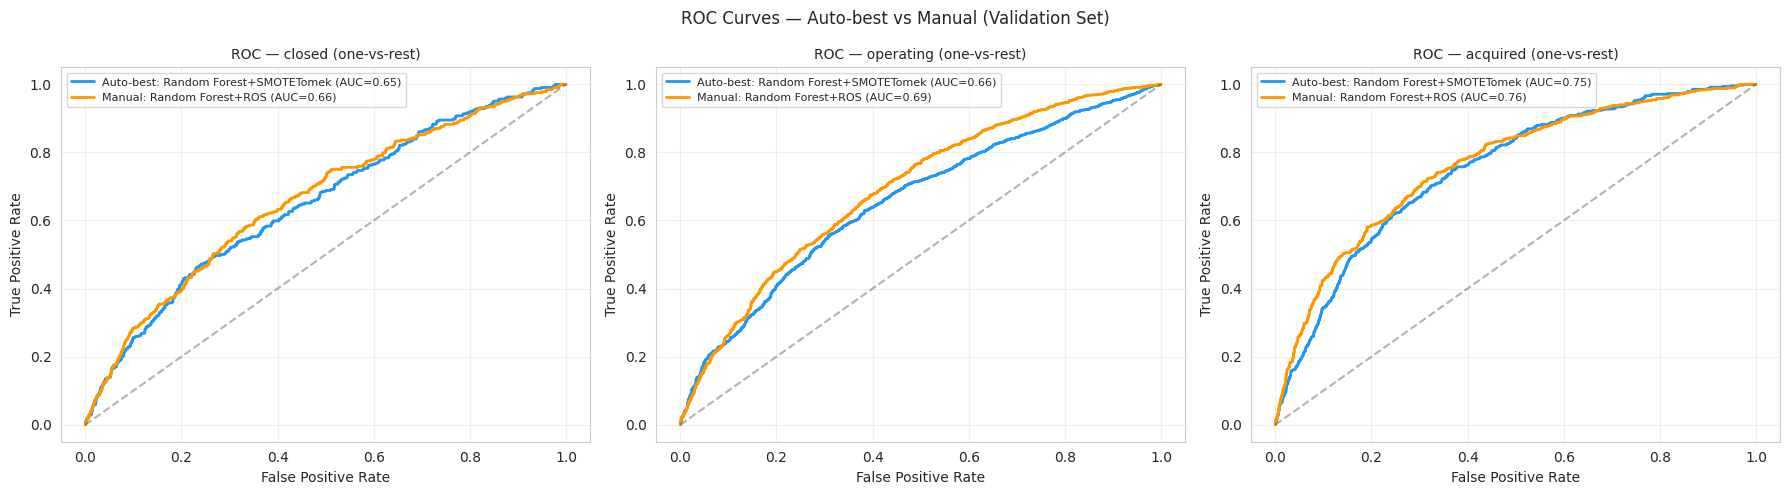

In [43]:
y_val_bin = label_binarize(y_val, classes=[0, 1, 2])

candidates = [
    ('Auto-best', auto_fitted,   auto_model,   auto_resample,   '#2196F3'),
    ('Manual',    manual_fitted, MANUAL_MODEL, MANUAL_RESAMPLE, '#FF9800'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for cls_idx, cls_name in enumerate(STATUS_NAMES):
    ax = axes[cls_idx]
    for label, fitted, mname, rname, color in candidates:
        try:
            proba = fitted.predict_proba(X_val_sel)[:, cls_idx]
            fpr, tpr, _ = roc_curve(y_val_bin[:, cls_idx], proba)
            roc_auc = auc(fpr, tpr)
            ax.plot(fpr, tpr, color=color, linewidth=2,
                    label=f'{label}: {mname}+{rname} (AUC={roc_auc:.2f})')
        except AttributeError:
            pass
    ax.plot([0,1],[0,1],'k--',alpha=0.3)
    ax.set_title(f'ROC — {cls_name} (one-vs-rest)', fontsize=10)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('ROC Curves — Auto-best vs Manual (Validation Set)', fontsize=12)
plt.tight_layout()
plt.show()


## 18. Full Validation Report — Both Candidates

Full `classification_report` for each candidate. After reviewing, confirm
`FINAL_MODEL_CHOICE` in Section 15 is set correctly before running Section 19.

In [44]:
for label, fitted, mname, rname in [
    ('AUTO-BEST', auto_fitted,   auto_model,   auto_resample),
    ('MANUAL',    manual_fitted, MANUAL_MODEL, MANUAL_RESAMPLE),
]:
    y_pred = fitted.predict(X_val_sel)
    print(f"{'='*60}")
    print(f" {label}: {mname} + {rname}")
    print(f" Accuracy : {accuracy_score(y_val, y_pred):.4f}")
    print(f"{'='*60}")
    print(classification_report(y_val, y_pred,
                                 target_names=STATUS_NAMES, zero_division=0))
    print()


 AUTO-BEST: Random Forest + SMOTETomek
 Accuracy : 0.7372
              precision    recall  f1-score   support

      closed       0.12      0.20      0.15       324
   operating       0.89      0.81      0.85      5164
    acquired       0.22      0.33      0.26       483

    accuracy                           0.74      5971
   macro avg       0.41      0.45      0.42      5971
weighted avg       0.79      0.74      0.76      5971


 MANUAL: Random Forest + ROS
 Accuracy : 0.5838
              precision    recall  f1-score   support

      closed       0.11      0.40      0.17       324
   operating       0.92      0.60      0.72      5164
    acquired       0.19      0.58      0.29       483

    accuracy                           0.58      5971
   macro avg       0.41      0.52      0.39      5971
weighted avg       0.82      0.58      0.66      5971




## 19. Final Evaluation on Test Set

> ⚠️ **Run this cell only once.** The test set has not been touched during any selection step.
>
> The model used is controlled by `FINAL_MODEL_CHOICE` in Section 15.
> **Confirm it is set correctly before running this cell.**
>
> `'auto'` → Auto-best model | `'manual'` → your hard-coded choice

 FINAL TEST SET — Random Forest [SMOTE]
 Selected via FINAL_MODEL_CHOICE = 'manual'
 Accuracy  (val)  : 0.7436
 Accuracy  (test) : 0.7444

              precision    recall  f1-score   support

      closed       0.13      0.20      0.16       324
   operating       0.88      0.82      0.85      5164
    acquired       0.20      0.28      0.23       483

    accuracy                           0.74      5971
   macro avg       0.41      0.44      0.42      5971
weighted avg       0.79      0.74      0.76      5971



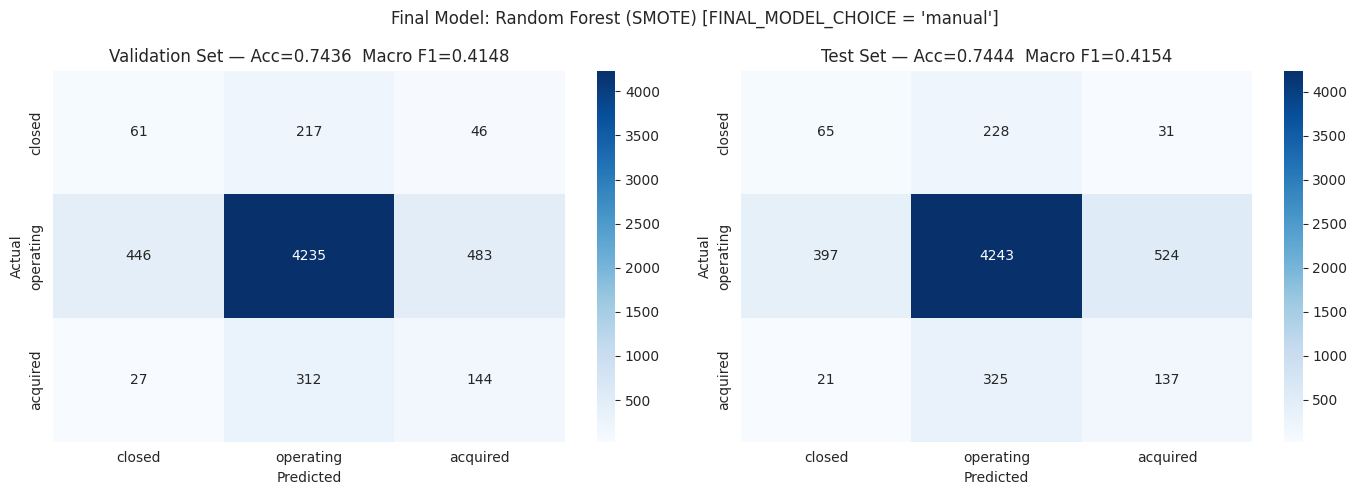

In [35]:
# ── Resolve final model from FINAL_MODEL_CHOICE ─────────────────────────
if FINAL_MODEL_CHOICE == 'auto':
    final_fitted   = auto_fitted
    final_model    = auto_model
    final_resample = auto_resample
    final_val_pred = auto_fitted.predict(X_val_sel)
else:  # 'manual'
    final_fitted   = manual_fitted
    final_model    = MANUAL_MODEL
    final_resample = MANUAL_RESAMPLE
    final_val_pred = manual_fitted.predict(X_val_sel)

y_pred_test = final_fitted.predict(X_test_sel)

print("="*60)
print(f" FINAL TEST SET — {final_model} [{final_resample}]")
print(f" Selected via FINAL_MODEL_CHOICE = '{FINAL_MODEL_CHOICE}'")
print("="*60)
print(f" Accuracy  (val)  : {accuracy_score(y_val,  final_val_pred):.4f}")
print(f" Accuracy  (test) : {accuracy_score(y_test, y_pred_test):.4f}")
print()
print(classification_report(y_test, y_pred_test,
                             target_names=STATUS_NAMES, zero_division=0))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, y_pred, split, y_true in zip(axes,
    [final_val_pred, y_pred_test],
    ['Validation',   'Test'],
    [y_val,          y_test]):
    cm  = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average='macro', zero_division=0)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=STATUS_NAMES, yticklabels=STATUS_NAMES)
    ax.set_title(f'{split} Set — Acc={acc:.4f}  Macro F1={f1:.4f}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle(f'Final Model: {final_model} ({final_resample}) '
             f'[FINAL_MODEL_CHOICE = {FINAL_MODEL_CHOICE!r}]', fontsize=12)
plt.tight_layout()
plt.show()


,Accuracy,F1 closed,F1 operating,F1 acquired,Prec closed,Prec operating,Prec acquired,Rec closed,Rec operating,Rec acquired
Validation,0.7436,0.1422,0.8531,0.2491,0.1142,0.8890,0.214,0.1883,0.8201,0.2981
Test,0.7444,0.1611,0.8520,0.2332,0.1346,0.8847,0.198,0.2006,0.8216,0.2836


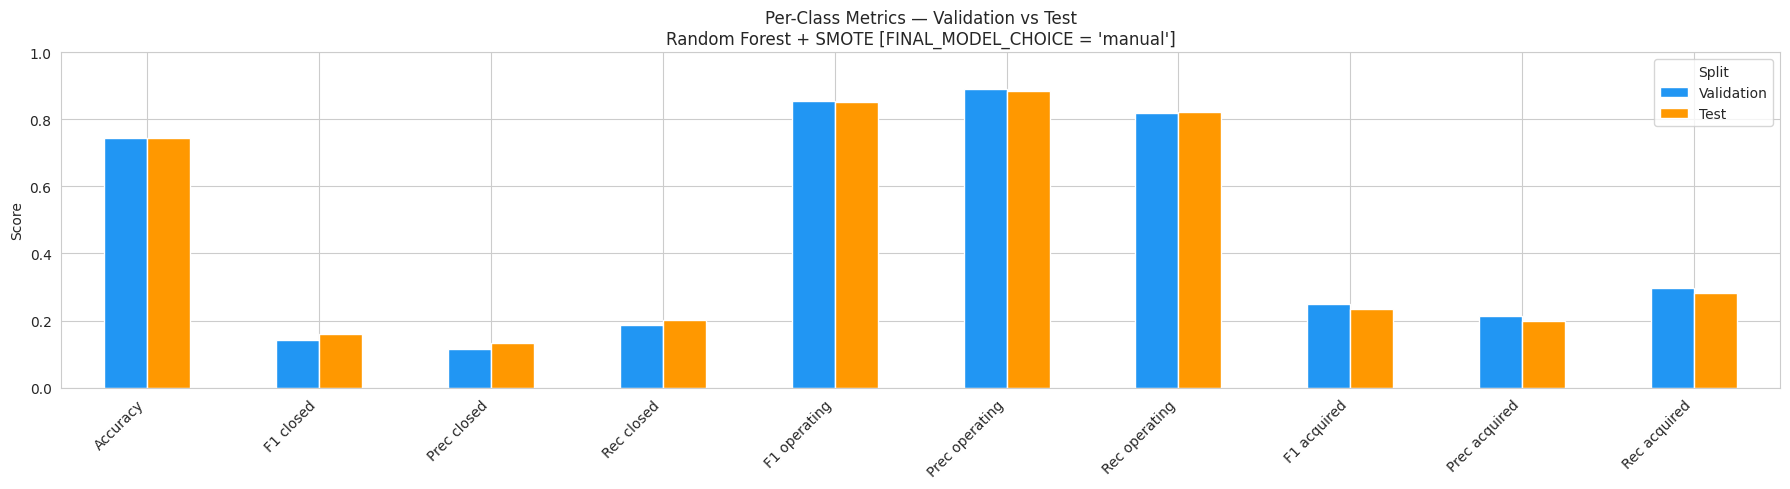

In [36]:
# Val vs Test — per-class P / R / F1 / Accuracy comparison
metrics_compare = {}
for split, y_true, y_pred in [
    ('Validation', y_val,  final_val_pred),
    ('Test',       y_test, y_pred_test)
]:
    f1_per   = f1_score(y_true, y_pred, average=None, labels=[0,1,2], zero_division=0)
    prec_per = precision_score(y_true, y_pred, average=None, labels=[0,1,2], zero_division=0)
    rec_per  = recall_score(y_true, y_pred, average=None, labels=[0,1,2], zero_division=0)
    metrics_compare[split] = {
        'Accuracy': accuracy_score(y_true, y_pred),
        **{f'F1 {c}':   v for c, v in zip(STATUS_NAMES, f1_per)},
        **{f'Prec {c}': v for c, v in zip(STATUS_NAMES, prec_per)},
        **{f'Rec {c}':  v for c, v in zip(STATUS_NAMES, rec_per)},
    }

compare_df = pd.DataFrame(metrics_compare).T
display(compare_df.round(4))

plot_cols = ['Accuracy'] + [f'{m} {c}' for c in STATUS_NAMES for m in ['F1','Prec','Rec']]
compare_df[plot_cols].T.plot(kind='bar', figsize=(18, 5),
                              color=['#2196F3','#FF9800'], edgecolor='white')
plt.title(f'Per-Class Metrics — Validation vs Test\n'
          f'{final_model} + {final_resample} [FINAL_MODEL_CHOICE = {FINAL_MODEL_CHOICE!r}]')
plt.ylabel('Score')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)
plt.legend(title='Split')
plt.tight_layout()
plt.show()


Feature importance for: Random Forest + SMOTE


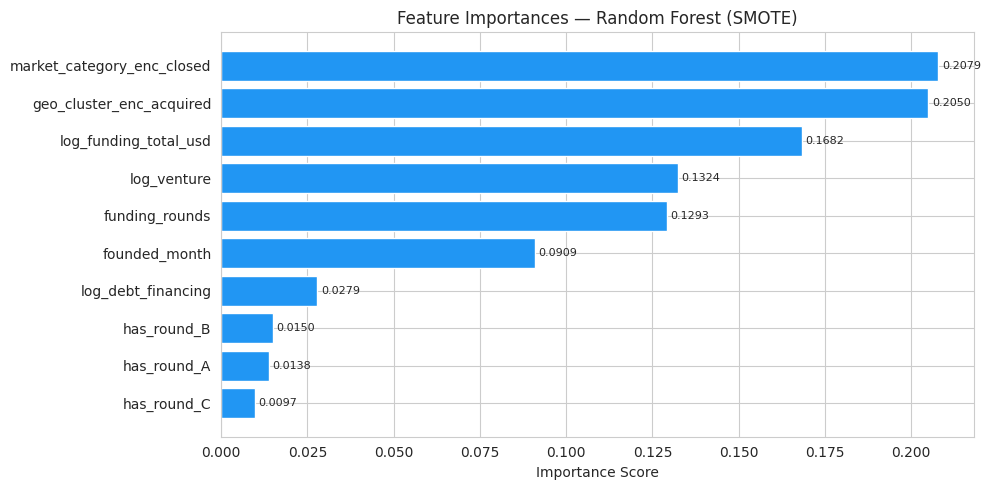

In [38]:
print(f"Feature importance for: {final_model} + {final_resample}")

if hasattr(final_fitted, 'feature_importances_'):
    imp_df = pd.DataFrame({
        'Feature':    selected_features,
        'Importance': final_fitted.feature_importances_
    }).sort_values('Importance', ascending=True)

    plt.figure(figsize=(10, max(5, len(selected_features) * 0.4)))
    bars = plt.barh(imp_df['Feature'], imp_df['Importance'],
                    color='#2196F3', edgecolor='white')
    for bar, v in zip(bars, imp_df['Importance']):
        plt.text(v + 0.001, bar.get_y() + bar.get_height()/2,
                 f'{v:.4f}', va='center', fontsize=8)
    plt.title(f'Feature Importances — {final_model} ({final_resample})', fontsize=12)
    plt.xlabel('Importance Score')
    plt.tight_layout()
    plt.show()

elif hasattr(final_fitted, 'coef_'):
    coef_mat = np.abs(final_fitted.coef_)
    imp_df = pd.DataFrame(coef_mat.T, index=selected_features, columns=STATUS_NAMES)
    imp_df['Mean |coef|'] = imp_df.mean(axis=1)
    imp_df = imp_df.sort_values('Mean |coef|', ascending=True)
    imp_df[STATUS_NAMES].plot(kind='barh',
                              figsize=(12, max(5, len(selected_features) * 0.4)),
                              color=COLORS, edgecolor='white')
    plt.title(f'Coefficient Magnitudes — {final_model} ({final_resample})', fontsize=12)
    plt.xlabel('|Coefficient|')
    plt.tight_layout()
    plt.show()


## Summary

### Feature Selection (Part A)
| Step | Method | Outcome |
|------|--------|---------|
| Filter | ANOVA F-test + Chi-squared | Statistical ranking of features |
| Correlation | Pearson matrix | Identified collinear pairs |
| Wrapper (importance) | RF, GB, Lasso, Ridge, SVM | Binary vote per method |
| Wrapper (sequential) | Forward Selection | Interaction-aware vote |
| Post-hoc | Permutation Importance | Val-set impact confirmation |
| **Aggregated** | **Vote ≥ 5 / 8** | **Final selected feature set** |

### Modeling (Part B)
| Step | Detail |
|------|--------|
| Resampling strategies | ROS, RUS, SMOTE, SMOTETomek |
| Models | LR (L1/L2), Random Forest, Gradient Boosting, XGBoost |
| Total runs | 4 strategies × 5 models = 20 combinations |
| Metrics tracked | Accuracy, Macro/Weighted F1 + Precision + Recall, per-class P/R/F1 |
| Regularization sweep | XGBoost reg_alpha × reg_lambda on best resampling |
| Selection criterion | **Macro F1** on validation set |
| Test evaluation | Single one-shot run in Section 19 |

### Output Files
| File | Description |
|------|-------------|
| `data/train_resampled_ros.csv` | ROS training set |
| `data/train_resampled_rus.csv` | RUS training set |
| `data/train_resampled_smote.csv` | SMOTE training set |
| `data/train_resampled_smotetomek.csv` | SMOTETomek training set |
| `data/val_processed.csv` | Validation — unchanged throughout |
| `data/test_processed.csv` | Test — used only in Section 19 |